# Detection

In [192]:
import torch
import torch.nn.functional as F
from torchvision import transforms
import matplotlib.pyplot as plt
from math import ceil, floor
import numpy as np
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from pathlib import Path
from torch import nn, optim
from torch.utils.data import DataLoader
from datetime import datetime
import matplotlib.pyplot as plt
import torch.nn.functional as F
from collections import Counter
from itertools import product
import math
import hashlib
import io
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import patches
from matplotlib.patches import Patch
import json
from torch.utils.data import TensorDataset
from shared_utils import intersection_union, Preprocessor, scale_vars, preprocess_out_noise, make_model_hash
from graphing import plot_class_counter, average_pixel_value, pixels_outside_inside_hist, confusion_matrix_custom, score_across_datasets
from constants import IMG_HEIGHT, IMG_WIDTH, DATA_DIR
from torch import Tensor
import json
from matplotlib import gridspec

# Setup

In [193]:
SEED = 265
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float32)

In [194]:
TOTAL_ROWS, TOTAL_COLS = 2, 3
BATCH_SIZE = 32

In [195]:
EPOCH_INVESTIGATE_POINTS = [1,5,10,15]
MAX_EPOCHS = 15

# for testing
# EPOCH_INVESTIGATE_POINTS = [1,2]
# MAX_EPOCHS = 2

In [196]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training on device {device}.")

Training on device cpu.


In [197]:
DO_TRAINING = False  # Set me to TRUE to run training from the start, otherwise we just load existing models

In [198]:
save_dir = Path("imgs/object_detection")
save_dir.mkdir(parents=True, exist_ok=True)

In [199]:
NUM_CLASSES = 2 # 0/1

### Load data + preprocess + normalize

In [200]:
# this is loaded to:
# 1. grab images
# 2. grab the actual transformed data, as a sanity check
dataset_train_imgs = torch.load(DATA_DIR / f"detection_train.pt", weights_only = False)
dataset_val_imgs = torch.load(DATA_DIR / f"detection_val.pt", weights_only = False)
dataset_test_imgs = torch.load(DATA_DIR / f"detection_test.pt", weights_only = False)

# we actually use these!
dataset_train = torch.load(DATA_DIR / f"list_y_true_train.pt", weights_only=False)
dataset_val = torch.load(DATA_DIR / f"list_y_true_val.pt", weights_only=False)
dataset_test = torch.load(DATA_DIR / f"list_y_true_test.pt", weights_only=False)

In [201]:
preprocessor = Preprocessor()
preprocessor.fit(dataset_train_imgs)

dataset_train_imgs = preprocessor.process(dataset_train_imgs)
dataset_val_imgs = preprocessor.process(dataset_val_imgs)
dataset_test_imgs = preprocessor.process(dataset_test_imgs)

In [202]:
print(len(dataset_train))
# looks like a good amount of data

26874


In [203]:
def global_to_local(x_g, y_g, w_g, h_g, rows=2, cols=3):
    # cell size
    cell_w = 1.0 / cols
    cell_h = 1.0 / rows

    # find cell of x,y
    col = int(x_g / cell_w)
    row = int(y_g / cell_h)

    # dont fall out of grid
    col = min(col, cols - 1)
    row = min(row, rows - 1)

    # from class
    x_local = (x_g - col * cell_w) / cell_w
    y_local = (y_g - row * cell_h) / cell_h
    w_local = w_g / cell_w
    h_local = h_g / cell_h

    return x_local, y_local, w_local, h_local, row, col

In [204]:
def local_to_global(x_l, y_l, w_l, h_l, row, col, rows=2, cols=3):
    cell_w = 1.0 / cols
    cell_h = 1.0 / rows

    # x_global = (cells to the left + offset within cell) * cell_width
    x_global = (col + x_l) * cell_w
    y_global = (row + y_l) * cell_h

    # w_global = w_local * cell_width
    w_global = w_l * cell_w
    h_global = h_l * cell_h

    return x_global, y_global, w_global, h_global

In [205]:
# sanity check from class:
global_to_local(0.6,0.6,0.2,0.2, rows=4, cols=3)

(0.8, 0.3999999999999999, 0.6000000000000001, 0.8, 2, 1)

In [206]:
# sanity check from class:
global_to_local(0.3,0.3,0.3,0.9, rows=4, cols=3)

(0.9, 0.19999999999999996, 0.9, 3.6, 1, 0)

Great, global to local is the same as the ones we computed in class!

Lets check using the pre-computed data

In [207]:
dataset_train_imgs[0][1][0][0]

tensor([1.0000, 0.7750, 0.8125, 0.3500, 0.7917, 1.0000])

In [208]:
dataset_train[0][0]

tensor([1.0000, 0.2583, 0.4062, 0.1167, 0.3958, 1.0000])

In [209]:
y_n, x,y,h,w,cla= dataset_train[0][0]
global_to_local(x,y,h,w)

(tensor(0.7750), tensor(0.8125), tensor(0.3500), tensor(0.7917), 0, 0)

OK! So global to local works and produces the same output as the preprocessed data. Happy days.

In [210]:
def plot_image(tensor_inp, ax):
    img_pixels, global_coords_ls = tensor_inp
    img = img_pixels.permute(1, 2, 0)

    ax.imshow(img)

    rows = 2
    cols = 3
    for r in range(1, rows):
        ax.axhline(y=r*IMG_HEIGHT/rows, color='white', linestyle='--', linewidth=1)
    for c in range(1, cols):
        ax.axvline(x=c*IMG_WIDTH/cols, color='white', linestyle='--', linewidth=1)

    items_in_img = set()

    for coords in global_coords_ls:
        is_item, x, y, w, h, class_label = coords
        items_in_img.add(int(class_label))

        scaled_x, scaled_y, scaled_w, scaled_h = scale_vars(x, y, w, h)

        ax.add_patch(
            patches.Rectangle(
                (scaled_x, scaled_y),
                scaled_w,
                scaled_h,
                linewidth=1,
                edgecolor='r',
                facecolor='none'
            )
        )

    ax.set_title(f"Image with class(es) {items_in_img}, has_item = {int(is_item)}")
    return ax

<Axes: title={'center': 'Image with class(es) {0, 1}, has_item = 1'}>

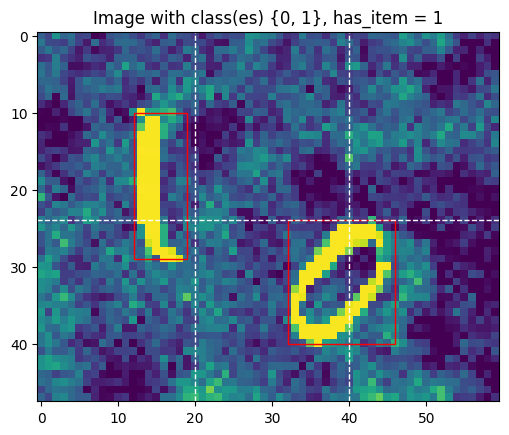

In [211]:
fig, axes = plt.subplots()

img = dataset_train_imgs[0][0]
global_coords = dataset_train[0]

plot_image((img, global_coords), axes)

In [212]:
global_coords = dataset_train[0][0]
actual_local = dataset_train_imgs[0][1][0][0]

is_item, x, y, h, w, class_item = global_coords

print("global cords:")
print(x,y,h,w)
print("\n")

x_loc, y_loc, w_loc, h_loc, _row, _col = global_to_local(x, y, h, w)

print("local cords:")
print(x_loc, y_loc, h_loc, w_loc)
print("\n")

print("actual local coords:")
print(actual_local)
print("\n")

col = int(x * TOTAL_COLS)
row = int(y * TOTAL_ROWS)

xg, yg, wg, hg = local_to_global(x_loc, y_loc, w_loc, h_loc, row, col)


print("global cords back again:")
print(xg, yg, hg, wg)
print("\n")

globals_check = [
        is_item,
        xg,
        yg,
        wg,
        hg,
        class_item
]

global cords:
tensor(0.2583) tensor(0.4062) tensor(0.1167) tensor(0.3958)


local cords:
tensor(0.7750) tensor(0.8125) tensor(0.7917) tensor(0.3500)


actual local coords:
tensor([1.0000, 0.7750, 0.8125, 0.3500, 0.7917, 1.0000])


global cords back again:
tensor(0.2583) tensor(0.4062) tensor(0.3958) tensor(0.1167)




In [213]:
assert(x, y, h, w) == (xg, yg, wg, hg)

Looks good

<Axes: title={'center': 'Image with class(es) {1}, has_item = 1'}>

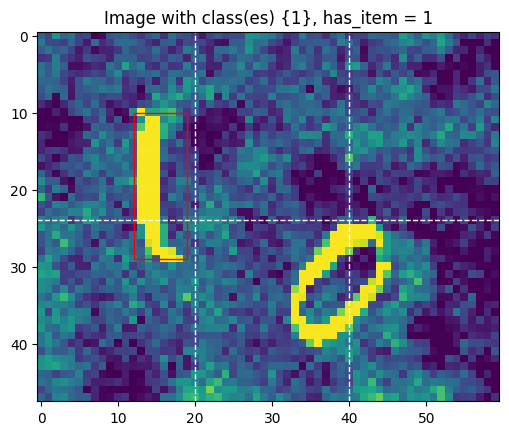

In [214]:
fig, axes = plt.subplots()
plot_image((img, [globals_check]), ax=axes)

Sanity check, yes we can convert the coordinates back and forth, great. Now let us combine the datasets, using our preprocessed items

In [215]:
# combine dataset
dataset_train = [(dataset_train_imgs[i][0], dataset_train[i]) for i in range(len(dataset_train))]
dataset_val = [(dataset_val_imgs[i][0], dataset_val[i]) for i in range(len(dataset_val))]
dataset_test = [(dataset_test_imgs[i][0], dataset_test[i]) for i in range(len(dataset_test))]

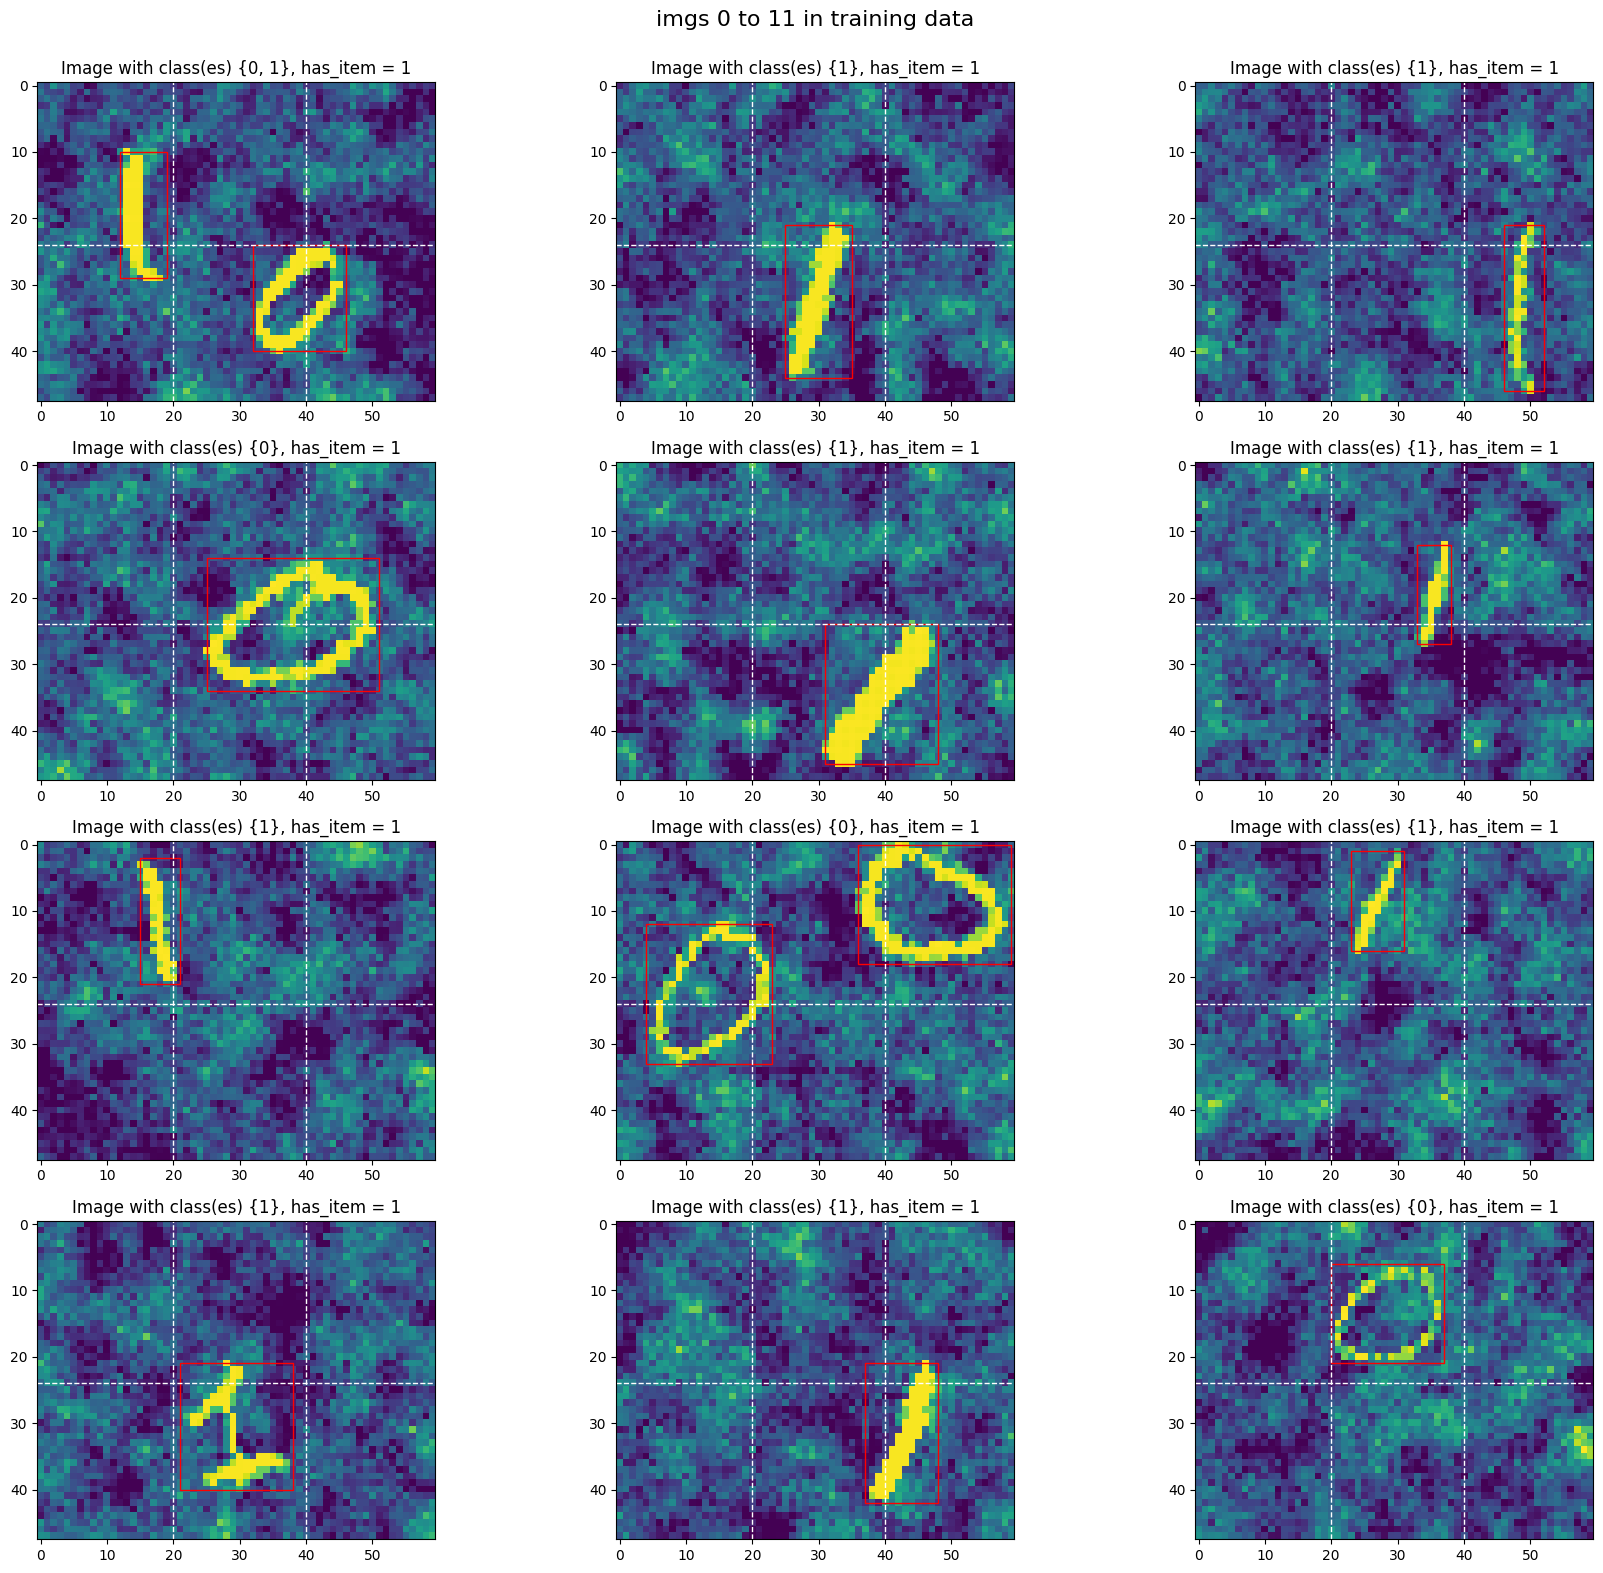

In [216]:
def plot_multiple(indicies: list, title: str, dataset, model_title):
    n = len(indicies)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    fig.suptitle(f"{title}", fontsize=16)

    for ax, index in zip(axes, indicies):
        plot_image(dataset[index], ax)

    for i in range(n, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    fig.savefig(save_dir / f"{model_title}.png", dpi=500)

    plt.show()

plot_multiple(
    [i for i in range(12)],
    "imgs 0 to 11 in training data",
    dataset_train,
    "data_explore_train"
)

In [217]:
all_targets = [int(bb[5]) for label in dataset_train for bb in label[1]]

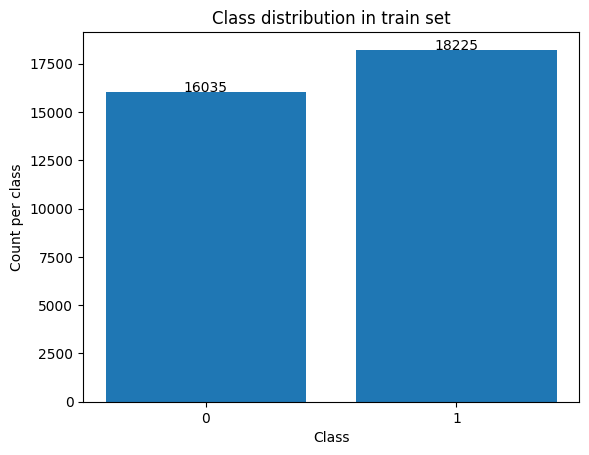

In [218]:
plot_class_counter(all_targets=all_targets, save_dir=save_dir)

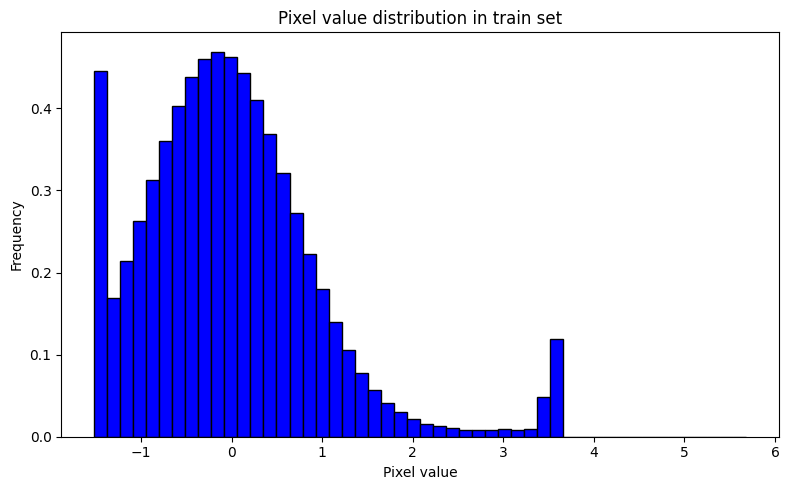

In [219]:
all_pixels = torch.cat([img_tensor[0].view(-1) for img_tensor in dataset_train])
average_pixel_value(all_pixels, save_dir)

Hmm strange, thats going on why do pixel values go above 3.7 ish?

In [220]:
def get_outliers(dataset, threshold = 3.7):
    outliers = []

    index = 0
    for img_tensor, _ in dataset:
        current_max = torch.max(img_tensor)
        if current_max > threshold:
            outliers.append((index,current_max))
        index+=1
    return outliers
outliers = get_outliers(dataset_train)
outliers

[(24487, tensor(5.6787))]

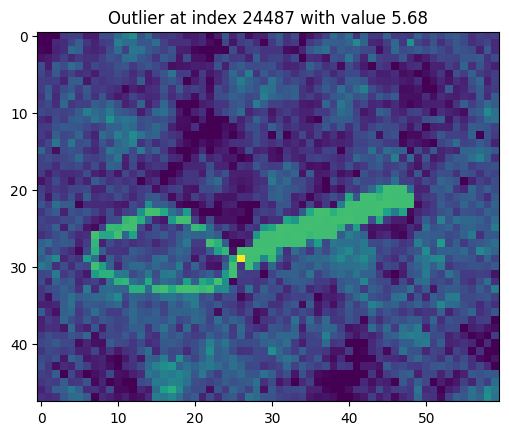

In [221]:
for idx,value in outliers:
    img, _ = dataset_train[idx]
    plt.imshow(img.permute(1, 2, 0))
    plt.title(f"Outlier at index {idx} with value {value:.3}")
    plt.savefig(save_dir / "outlier.png")
plt.show()

Ok so we have an outlier at index 24487! Considering only one image has this very weird pixel, we can saftley delete it i suppose.

In [222]:
del dataset_train[24487]

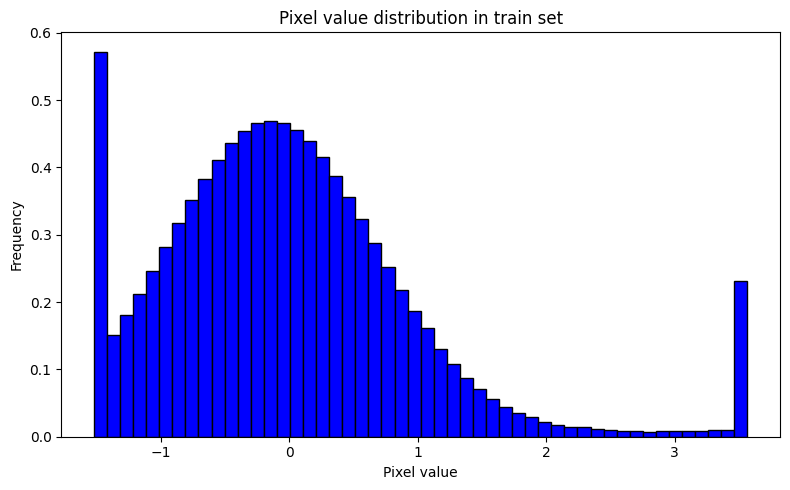

In [223]:
all_pixels = torch.cat([img_tensor[0].view(-1) for img_tensor in dataset_train])
average_pixel_value(all_pixels, save_dir)

In [224]:
def grab_pixels_inside_outside_bb(dataset):
    pixels_inside = []
    pixels_outside = []

    for img_tensor, bbs_list in dataset:
        _, H, W = img_tensor.shape
        img = img_tensor[0]

        master_mask = torch.zeros(H, W, dtype=torch.bool)

        for bb in bbs_list:
            is_item, x, y, h, w, _class = bb

            if is_item == 0:
                continue

            x_center, y_center = x * W, y * H
            w_px, h_px = w * W, h * H

            x1 = int(max(0, x_center - w_px / 2))
            x2 = int(min(W, x_center + w_px / 2))
            y1 = int(max(0, y_center - h_px / 2))
            y2 = int(min(H, y_center + h_px / 2))

            master_mask[y1:y2, x1:x2] = True

        pixels_inside.append(img[master_mask])
        pixels_outside.append(img[~master_mask])

    return torch.cat(pixels_inside), torch.cat(pixels_outside)

pixels_inside, pixels_outside = grab_pixels_inside_outside_bb(dataset_train)

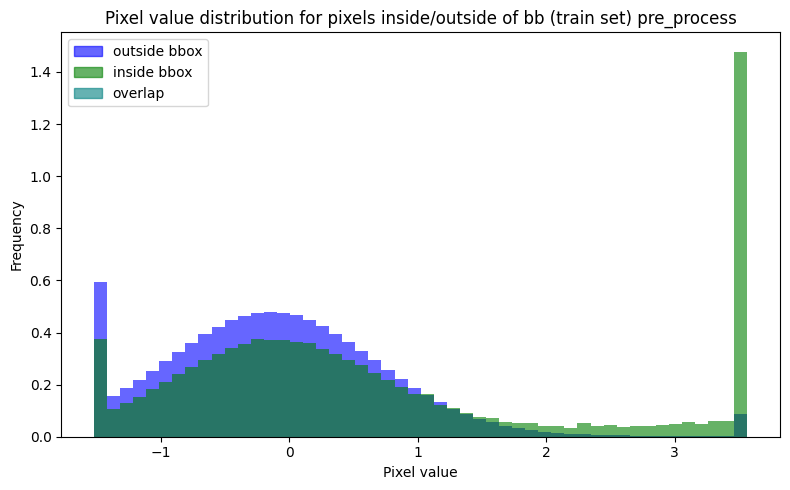

In [225]:
pixels_outside_inside_hist(pixels_inside, pixels_outside, save_dir, "pre_process")

In [226]:
dataset_train_processed = [preprocess_out_noise(sample) for sample in dataset_train]
dataset_val_processed = [preprocess_out_noise(sample) for sample in dataset_val]
dataset_test_processed = [preprocess_out_noise(sample) for sample in dataset_test]

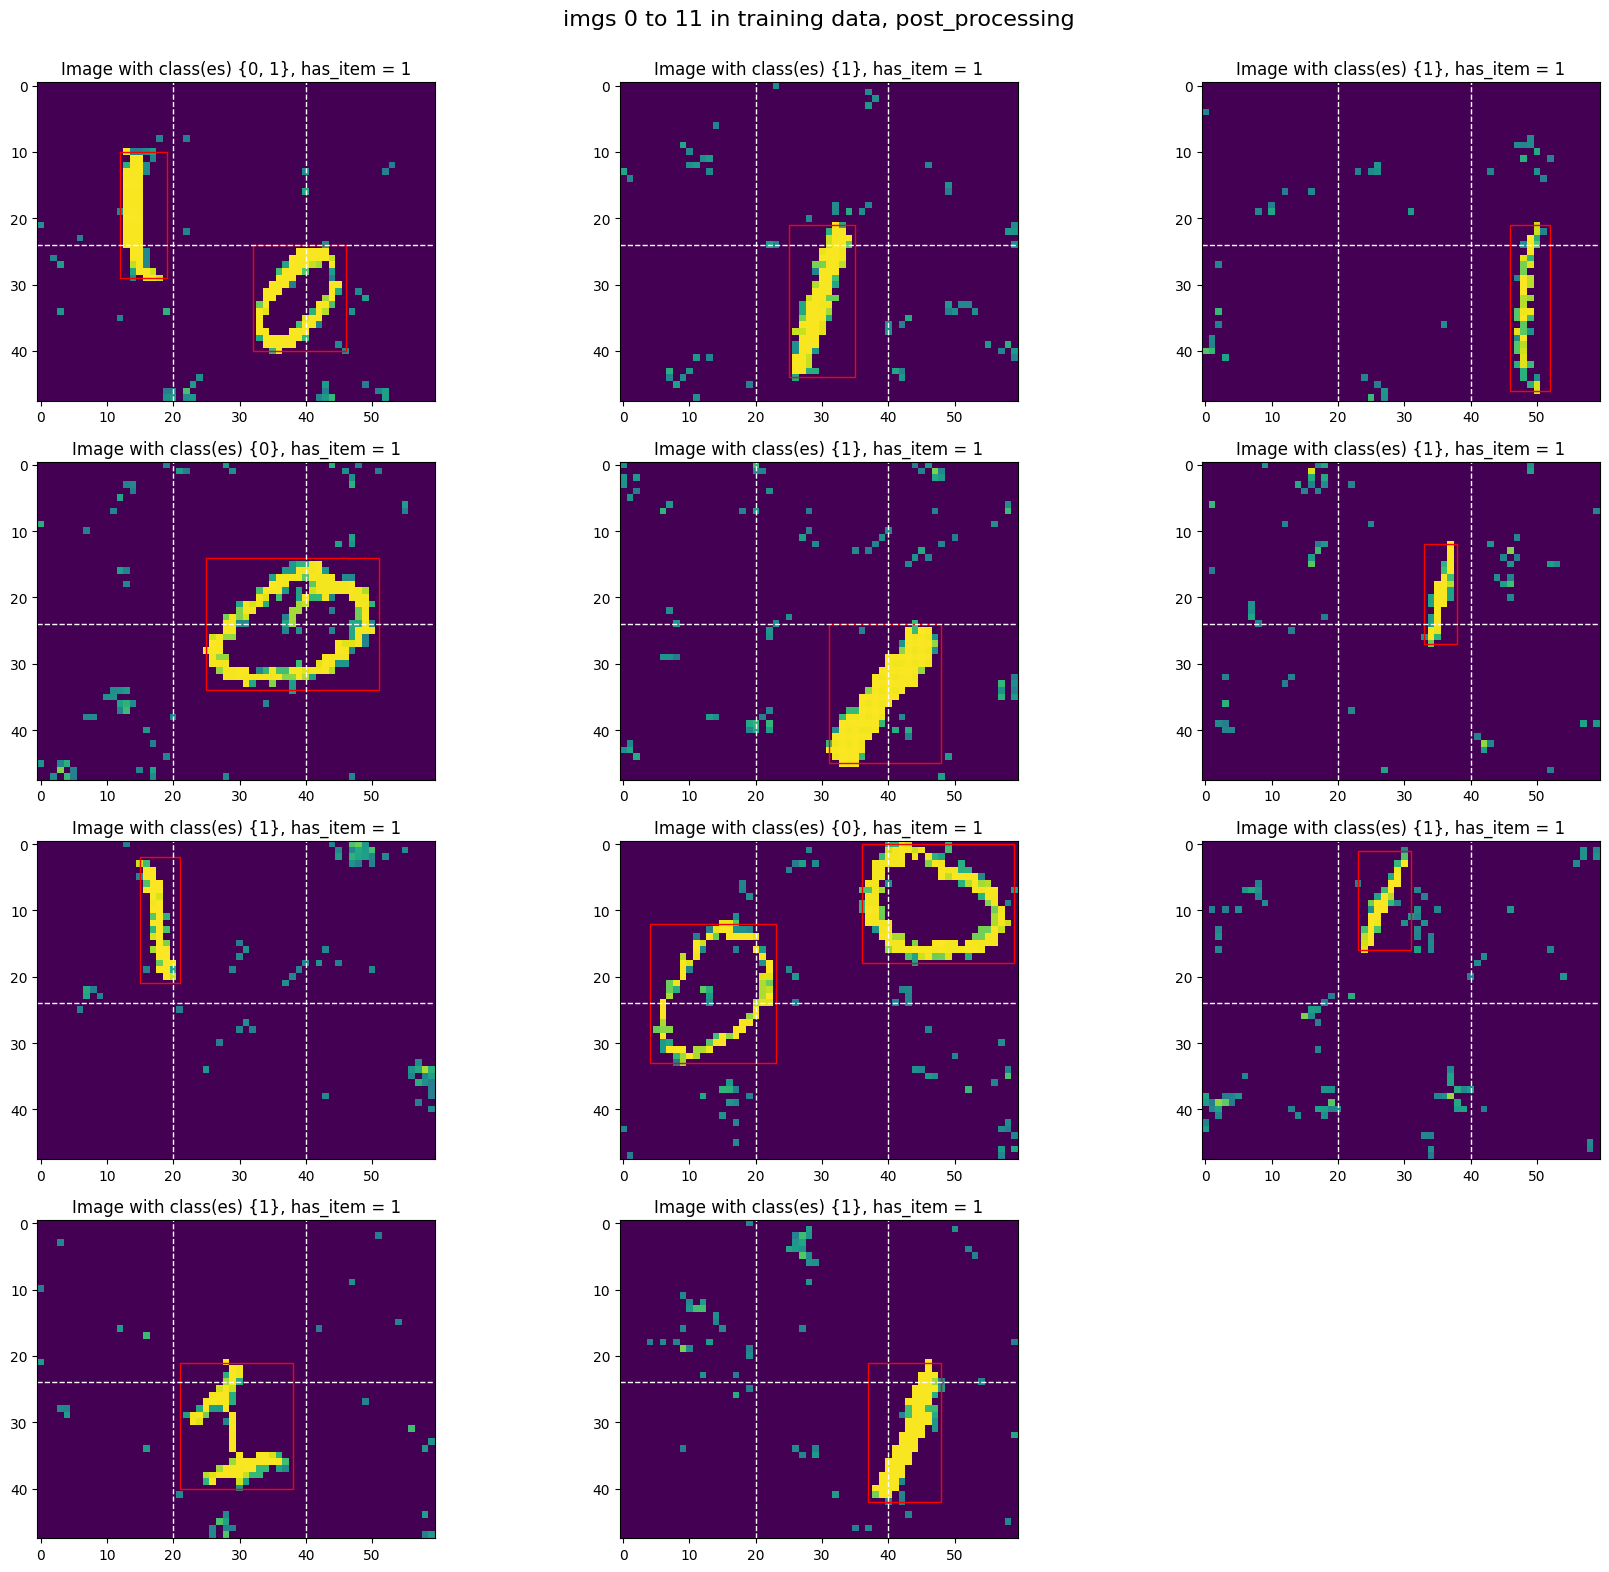

In [227]:
plot_multiple(
    [i for i in range(11)],
    "imgs 0 to 11 in training data, post_processing",
    dataset_train_processed,
    "data_explore_train_post_process"
)

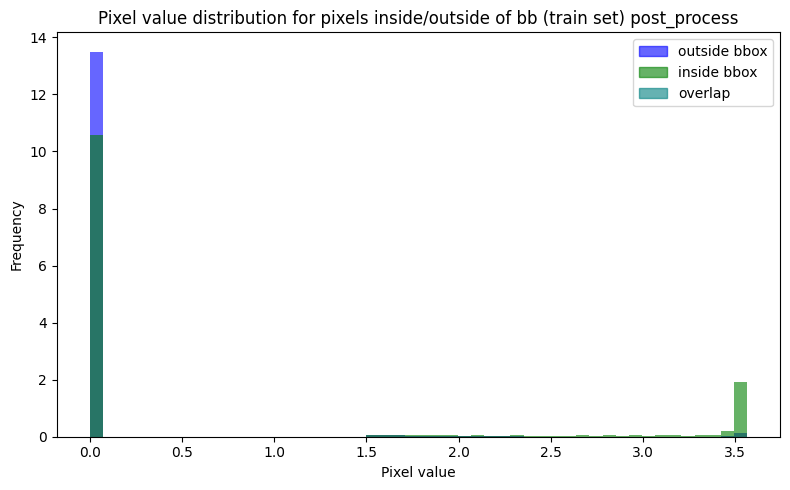

In [228]:
pixels_inside_processed, pixels_outside_processed = grab_pixels_inside_outside_bb(dataset_train_processed)
pixels_outside_inside_hist(pixels_inside_processed, pixels_outside_processed, save_dir=save_dir, label="post_process")

In [229]:
def build_grid_labels(global_labels_list, rows=2, cols=3):
    """
    bb list fo always have 6
    """
    # (2, 3, 6) -> [yes_no, x, y, w, h, class]
    grid = torch.zeros((rows, cols, 6))

    for bb in global_labels_list:
        is_item, x_g, y_g, h_g, w_g, class_label = bb

        if is_item == 0:
            continue

        xl, yl, wl, hl, row, col = global_to_local(x_g, y_g, w_g, h_g, rows, cols)

        grid[row, col, 0] = 1.0
        grid[row, col, 1] = xl
        grid[row, col, 2] = yl
        grid[row, col, 3] = wl
        grid[row, col, 4] = hl
        grid[row, col, 5] = class_label

    return grid

dataset_train_grid = [
    (dataset_train_processed[i][0], build_grid_labels(dataset_train_processed[i][1]))
    for i in range(len(dataset_train_processed))
]

dataset_val_grid = [
    (dataset_val_processed[i][0], build_grid_labels(dataset_val_processed[i][1]))
    for i in range(len(dataset_val_processed))
]

dataset_test_grid = [
    (dataset_test_processed[i][0], build_grid_labels(dataset_test_processed[i][1]))
    for i in range(len(dataset_test_processed))
]

In [230]:
train_loader_grid = DataLoader(dataset_train_grid, batch_size=BATCH_SIZE, shuffle=True)
# shuffle is true to let images go in a random order
val_loader_grid = DataLoader(dataset_val_grid, batch_size=BATCH_SIZE, shuffle=False)
test_loader_grid = DataLoader(dataset_test_grid, batch_size=BATCH_SIZE, shuffle=False)

In [231]:
dataset_train_grid[1][1][1][1]

tensor([1.0000, 0.5000, 0.3542, 1.4375, 0.3333, 1.0000])

In [507]:
logits_loss = nn.BCEWithLogitsLoss()
cross_entropy = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()

def per_cell_localization_loss(pred, actual):
    """
    Loss function for a neural network with pred/actual vectors like:
    [
     z : is there an object in the image?
     x : coords
     y : coords
     w : coords
     h : coords
     c1 : class 1 probability
     c2
     c3
     ...
     c_n : class n probability
    ]
    in a 2*3 grid
    """
    pred_flat = pred.reshape(-1, 7)
    actual_flat = actual.reshape(-1, 6)

    # grab all values
    z_actual, z_pred = actual_flat[:, 0], pred_flat[:, 0]
    bb_actual, bb_pred = actual_flat[:, 1:5], pred_flat[:, 1:5]
    class_actual, class_pred = actual_flat[:, 5].long(), pred_flat[:, 5:]

    # see what case we are in

    is_object_mask = z_actual == 1

    # both branches do this
    total_loss = logits_loss(z_pred, z_actual) # -log(sigmoid(z)), yes/no loss

    if is_object_mask.any():
        total_loss += mse_loss(bb_pred[is_object_mask], bb_actual[is_object_mask])
        total_loss += cross_entropy(class_pred[is_object_mask], class_actual[is_object_mask].long())
    return total_loss

## Localization


In [ ]:
def xywh_to_xyxy(bb):
    # convert from center format to box format
    x_center, y_center, w, h = bb
    x1 = x_center - w/2
    y1 = y_center - h/2
    x2 = x_center + w/2
    y2 = y_center + h/2
    return x1, y1, x2, y2


def get_map_results(model, eval_loader):
    '''
        Helper functions to get predictions and targets in the format required for mAP calculation.
        Depending on your data processing and model architecture this function can either be used as is, 
        modified to fit your needs or used as a blue print for a rewrite.
        Here it is assussmed that the image has been divide into a 2 x 3 grid.
        ----------------------------------------------------------
        Run through the data in the dataloader and collect predicitions and targets for mAP calculation.

        torchmetric mAP expects predictions and targets in the format:
        preds = [
            { "boxes": tensor([[x1, y1, x2, y2], ...]), "scores": tensor([score1, score2, ...]), "labels": tensor([label1, label2, ...])},
            ...   ]
        and targets = [
            { "boxes": tensor([[x1, y1, x2, y2], ...]), "labels": tensor([label1, label2, ...])},
            ...   ]
        where each dict in the list corresponds to one image in the dataset and contains the predicted and true results
    '''

    model.eval()
    with torch.no_grad():
        preds = []
        targets = []
        for images, labels in eval_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # go from B, 2, 3, 7 to B, 6, 7
            outputs = outputs.permute(0, 2, 3, 1) if outputs.shape[1] == 7 else outputs
            outputs = outputs.reshape(outputs.shape[0], -1, 7)
            labels = labels.reshape(labels.shape[0], -1, 6)

            for output, label in zip(outputs, labels):
                pred_boxes, pred_scores, pred_labels = [], [], []
                target_boxes, target_labels = [], []

                for i, cell_output in enumerate(output):
                    pc_logit = cell_output[0]

                    if torch.sigmoid(pc_logit) > 0.5:
                        obj_prob = torch.sigmoid(pc_logit).item()

                        class_logits = cell_output[5:]

                        # if we pred image
                        if class_logits.numel() > 0:
                            class_probs = F.softmax(class_logits, dim=0)
                            pred_label = torch.argmax(class_probs)
                            detect_score = obj_prob * class_probs[pred_label].item()

                            row, col = i // 3, i % 3
                            xl, yl, wl, hl = cell_output[1:5]

                            bbox_global = local_to_global(xl, yl, wl, hl, row, col)
                            bbox_xyxy = torch.stack(xywh_to_xyxy(bbox_global))

                            pred_boxes.append(bbox_xyxy)
                            pred_scores.append(detect_score)
                            pred_labels.append(pred_label)

                # targets
                for i, cell_label in enumerate(label):
                    if cell_label[0] == 1:
                        row, col = i // 3, i % 3
                        xl, yl, wl, hl = cell_label[1:5]
                        bbox_global = local_to_global(xl, yl, wl, hl, row, col)
                        bbox_xyxy = torch.stack(xywh_to_xyxy(bbox_global))
                        target_boxes.append(bbox_xyxy)
                        target_labels.append(cell_label[5].long())

                # format
                if not pred_boxes:
                    preds.append({
                        "boxes": torch.zeros((0, 4), device=device),
                        "scores": torch.zeros((0,), device=device),
                        "labels": torch.zeros((0,), dtype=torch.long, device=device)
                    })
                else:
                    preds.append({
                        "boxes": torch.stack(pred_boxes),
                        "scores": torch.tensor(pred_scores, device=device),
                        "labels": torch.stack(pred_labels)
                    })

                if not target_boxes:
                    targets.append({
                        "boxes": torch.zeros((0, 4), device=device),
                        "labels": torch.zeros((0,), dtype=torch.long, device=device)
                    })
                else:
                    targets.append({
                        "boxes": torch.stack(target_boxes),
                        "labels": torch.stack(target_labels)
                    })

    metric = MeanAveragePrecision(iou_type="bbox")
    metric.update(preds, targets)
    map = metric.compute()
    return map


### Training

same conf = p - (k-1) / 2
dim_new = ((dim_old - k + 2padding) / stride) +1

In [ ]:
class ModelOutcome:
    def __init__(
        self,
        train_losses: list,
        val_losses: list,
        params: dict,
        train_performance_metrics: list[float],
        val_performance_metrics: list[float],
        model_path: Path,
    ):
        self.train_losses = train_losses
        self.val_losses = val_losses

        self.params = params

        self.train_performance_metrics = train_performance_metrics
        self.val_performance_metrics = val_performance_metrics

        self.model_path = model_path

    def to_dict(self) -> dict:
        def convert(obj):
            # tensors dont want to be converted so we have to
            # help json understand tensors
            if isinstance(obj, torch.Tensor):
                if obj.numel() == 1:
                    return obj.item()
                else:
                    return obj.tolist()
            elif isinstance(obj, dict):
                return {k: convert(v) for k, v in obj.items()}
            elif isinstance(obj, list):
                return [convert(v) for v in obj]
            else:
                return obj

        return {
            "train_losses": [float(x) for x in self.train_losses],
            "val_losses": [float(x) for x in self.val_losses],
            "params": self.params,
            "train_performance_metrics": convert(self.train_performance_metrics),
            "val_performance_metrics": convert(self.val_performance_metrics),
            "model_path": str(self.model_path) if self.model_path else None,
        }

    @staticmethod
    def from_dict(d: dict):
        return ModelOutcome(
            train_losses=d["train_losses"],
            val_losses=d["val_losses"],
            params=d["params"],
            train_performance_metrics={int(k): v for k, v in d["train_performance_metrics"].items()},
            val_performance_metrics={int(k): v for k, v in d["val_performance_metrics"].items()},
            model_path=Path(d["model_path"]) if d.get("model_path") else None,
        )

In [510]:
class CNNBaselineNoBatch(nn.Module):
    """
    4 conv into maxpool layers
    """
    def __init__(self):
        super().__init__()

        # inp: 48, 60
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1) # keep same dimensions
        self.pool1 = nn.MaxPool2d(2, 2) # 24 x 30

        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1) # keep same dimensions
        self.pool2 = nn.MaxPool2d(2, 2) # 16 x 12 x 15

        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # keep same dimensions
        self.pool3 = nn.MaxPool2d(2, 2) # 32 x 6 x 7

        # used formula from class here:
        # dim_2 = ((dim_1 + (2*padding) - kernel) / stride) +1
        # to get uneven kernel size

        self.conv4 = nn.Conv2d(32, 64, kernel_size=(3,2)) # 32 * 4*6
        self.pool4 = nn.MaxPool2d(2, 2) # 32 x 2 * 3

        # 1*yes/no, 4*coords, 2*classes = 7
        self.predictor = nn.Conv2d(64, 5 + NUM_CLASSES, kernel_size=1)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = self.pool4(F.relu(self.conv4(x)))
        x = self.predictor(x)
        # no special output since we are using a custom loss function!
        return x.permute(0, 2, 3, 1)

    def name(self):
        return "CNNBaselineNoBatch"

In [511]:
class CNNBaselineWithBatch(nn.Module):
    """
    4 conv into maxpool layers
    """
    def __init__(self):
        super().__init__()

        # inp: 48, 60
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1) # keep same dimensions
        self.bn1 = nn.BatchNorm2d(8)
        self.pool1 = nn.MaxPool2d(2, 2) # 24 x 30

        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1) # keep same dimensions
        self.bn2 = nn.BatchNorm2d(16)
        self.pool2 = nn.MaxPool2d(2, 2) # 16 x 12 x 15

        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # keep same dimensions
        self.bn3 = nn.BatchNorm2d(32)
        self.pool3 = nn.MaxPool2d(2, 2) # 32 x 6 x 7

        # used formula from class here:
        # dim_2 = ((dim_1 + (2*padding) - kernel) / stride) +1
        # to get uneven kernel size

        self.conv4 = nn.Conv2d(32, 64, kernel_size=(3,2)) # 32 * 4*6
        self.bn4 = nn.BatchNorm2d(64)
        self.pool4 = nn.MaxPool2d(2, 2) # 32 x 2 * 3

        # 1*yes/no, 4*coords, 2*classes = 7
        self.predictor = nn.Conv2d(64, 5 + NUM_CLASSES, kernel_size=1)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        x = self.predictor(x)
        # no special output since we are using a custom loss function!
        return x.permute(0, 2, 3, 1)

    def name(self):
        return "CNNBaselineWithBatch"

In [ ]:
class CNNLargeKernels(nn.Module):
    def __init__(self):
        super().__init__()

        # Input: 48 x 60
        self.conv1 = nn.Conv2d(1, 8, kernel_size=7, padding=2)
        # (48 + 4 - 7) + 1 = 46 | (60 + 4 - 7) + 1 = 58
        self.bn1 = nn.BatchNorm2d(8)
        self.pool1 = nn.MaxPool2d(2, 2) # 23 x 29

        self.conv2 = nn.Conv2d(8, 16, kernel_size=5, padding=1)
        # (23 + 2 - 5) + 1 = 21 | (29 + 2 - 5) + 1 = 27
        self.bn2 = nn.BatchNorm2d(16)
        self.pool2 = nn.MaxPool2d(2, 2) # 10 x 13

        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=0)
        # (10 - 3) + 1 = 8 | (13 - 3) + 1 = 11
        self.bn3 = nn.BatchNorm2d(32)
        self.pool3 = nn.MaxPool2d(2, 2) # 4 x 5

        self.conv4 = nn.Conv2d(32, 64, kernel_size=3, padding=0)
        self.bn4 = nn.BatchNorm2d(64)

        self.predictor = nn.Conv2d(64, 5 + NUM_CLASSES, kernel_size=1)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.predictor(x)

        return x.permute(0, 2, 3, 1)

    def name(self):
        return "CNNLargeKernels"

In [513]:
class ResBlock(nn.Module):
    def __init__(self, channels, stride = 1, kernel_size = 3, padding = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, stride = stride, kernel_size=kernel_size, padding=padding)
        self.bn1 = nn.BatchNorm2d(channels)

        self.conv2 = nn.Conv2d(channels, channels, stride=1, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

        # to turn down the size in final transform
        self.downsample = None
        if stride != 1 or kernel_size != 3 or padding != 1:
            self.downsample = nn.Sequential(
                nn.Conv2d(channels, channels, kernel_size=kernel_size,stride=stride, padding=padding),
                nn.BatchNorm2d(channels)
            )

    def forward(self, x):
        residual = x

        # downsample the residual to make math work
        if self.downsample is not None:
            residual = self.downsample(x)

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)

class CNNResNet(nn.Module):
    def __init__(self):
        super().__init__()

        # 48 * 60
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1) # keep dimensions
        self.bn1 = nn.BatchNorm2d(32)
        self.layer1 = ResBlock(32)
        self.pool1 = nn.MaxPool2d(2, 2) # halve to 24x30

        # 1x1 convolution, more channels
        self.downsample2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=1),
            nn.BatchNorm2d(64)
        )

        self.layer2 = ResBlock(64)
        self.pool2 = nn.MaxPool2d(2, 2) # halve to 12 * 15

        # 1x1 convolution again for more channels
        self.downsample3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=1),
            nn.BatchNorm2d(128)
        )

        self.layer3 = ResBlock(128)
        self.pool3 = nn.MaxPool2d(2, 2) # 6*7

        # 1x1 convolution again for more channels
        self.downsample4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=1),
            nn.BatchNorm2d(256)
        )

        self.layer4 = ResBlock(256, stride=2, kernel_size=3, padding=0) # 256 * 2 3

        # predict
        self.predictor = nn.Conv2d(256, 5 + NUM_CLASSES, kernel_size=1)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))

        x = self.layer1(x)
        x = self.pool1(x)

        x = self.downsample2(x)
        x = self.layer2(x)
        x = self.pool2(x)

        x = self.downsample3(x)
        x = self.layer3(x)
        x = self.pool3(x)

        x = self.downsample4(x)
        x = self.layer4(x)

        x = self.predictor(x)
        # no special output since we are using a custom loss function!
        return x.permute(0, 2, 3, 1)

    def name(self):
        return "CNNResNet"

In [514]:
class CNNDenseNet(nn.Module):
    def __init__(self):
        super().__init__()

        # initial conv
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1) # keep size
        self.bn1 = nn.BatchNorm2d(16)

        # dense block 1
        self.conv2 = nn.Conv2d(16, 16, kernel_size=3, padding=1) # keep size
        self.bn2 = nn.BatchNorm2d(16)

        self.conv3 = nn.Conv2d(32, 16, kernel_size=3, padding=1) # keep size
        self.bn3 = nn.BatchNorm2d(16)

        self.pool1 = nn.MaxPool2d(2, 2)  # halve to 24x30

        # dense block 2
        self.conv4 = nn.Conv2d(48, 32, kernel_size=3, padding=1)  # keep size
        self.bn4 = nn.BatchNorm2d(32)

        self.conv5 = nn.Conv2d(80, 32, kernel_size=3, padding=1)  # keep size
        self.bn5 = nn.BatchNorm2d(32)

        self.pool2 = nn.MaxPool2d(2, 2)  # halve to 12x15

        # transition layer to reduce channels
        self.conv6 = nn.Conv2d(112, 64, kernel_size=1) # keep size
        self.bn6 = nn.BatchNorm2d(64)

        self.pool3 = nn.MaxPool2d(2, 2)  # halve to 6x7

        self.conv7 = nn.Conv2d(64, 64, kernel_size=(5, 5)) # turn into 2 * 3

        self.bn7 = nn.BatchNorm2d(64)

        self.predictor = nn.Conv2d(64, 5 + NUM_CLASSES, kernel_size=1)

    def forward(self, x):
        # first layer
        x1 = F.relu(self.bn1(self.conv1(x)))  # 16

        # dense block 1
        x2 = F.relu(self.bn2(self.conv2(x1)))  # 16
        x3 = F.relu(self.bn3(self.conv3(torch.cat([x1, x2], dim=1))))  # 16

        x = torch.cat([x1, x2, x3], dim=1)  # 48
        x = self.pool1(x)

        # dense block 2
        x4 = F.relu(self.bn4(self.conv4(x)))  # 32
        x5 = F.relu(self.bn5(self.conv5(torch.cat([x, x4], dim=1))))  # 32

        x = torch.cat([x, x4, x5], dim=1)  # 112
        x = self.pool2(x)

        # transition
        x = F.relu(self.bn6(self.conv6(x)))  # 64

        x = self.pool3(x)

        x = F.relu(self.bn7(self.conv7(x)))  # 64

        x = self.predictor(x)
        # no special output since we are using a custom loss function!
        return x.permute(0, 2, 3, 1)


    def name(self):
        return "CNNDenseNet"

In [515]:
per_cell_loss_localization = per_cell_localization_loss

In [516]:
def train(
    n_epochs,
    optimizer,
    model,
    loss_fn,
    train_loader_inp: DataLoader,
    validation_loader_inp: DataLoader,
):
    n_batch_train = len(train_loader_inp)
    n_batch_val = len(validation_loader_inp)

    losses_train, losses_val = [], []
    train_performance_metrics, val_performance_metrics = {}, {}

    model.train()  # set to train mode
    optimizer.zero_grad(set_to_none=True)

    for epoch in range(1, n_epochs + 1):
        loss_train, loss_val = 0.0, 0.0

        for imgs, labels in train_loader_inp:
            imgs = imgs.to(device=device, dtype=torch.float32)
            labels = labels.to(device=device)

            outputs = model(imgs)

            loss = loss_fn(outputs, labels)
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

            loss_train += loss.item()

        model.eval()  # observe model performance
        with torch.no_grad():
            for val_imgs, val_labels in validation_loader_inp:
                imgs_val = val_imgs.to(device=device, dtype=torch.float32)
                val_labels = val_labels.to(device=device, dtype=torch.float32)
                val_outputs = model(imgs_val)
                val_loss = loss_fn(val_outputs, val_labels)
                loss_val += val_loss.item()

        if epoch in EPOCH_INVESTIGATE_POINTS:
            # map_metric, obj_acc, class_acc
            train_performance_metrics[epoch] = get_map_results(model, train_loader_inp)
            val_performance_metrics[epoch] = get_map_results(model, validation_loader_inp)

        model.train()

        losses_train.append(loss_train / n_batch_train)
        losses_val.append(loss_val / n_batch_val)

        if epoch == 1 or epoch % 5 == 0:
            print(
                "{}  |  Epoch {}  |  Training loss {:.3f} Validation loss {:.3f}".format(
                    datetime.now().time(), epoch, loss_train / n_batch_train, loss_val / n_batch_val
                )
            )
    return losses_train, losses_val, train_performance_metrics, val_performance_metrics

In [517]:
model_baseline = CNNBaselineNoBatch().to(device)

In [518]:
if DO_TRAINING:
    object_detection_optimizer = optim.Adam(model_baseline.parameters())

    train_losses, validation_losses, train_performance_metrics, val_performance_metrics = train(
        n_epochs=MAX_EPOCHS,
        optimizer=object_detection_optimizer,
        model=model_baseline,
        loss_fn=per_cell_loss_localization,
        train_loader_inp=train_loader_grid,
        validation_loader_inp=val_loader_grid,
    )
# here

In [ ]:
def plot_train_val_losses(
    train_losses,
    val_losses,
    train_acc,
    val_acc,
    params=None,
    ax_plot=None,
    ax_table=None,
    title=None,
    figsize=(8, 5)
):
    """
    Plot training/validation loss and place a metrics table below the plot.
    """

    # if alone
    if ax_plot is None or ax_table is None:
        fig = plt.figure(figsize=figsize, constrained_layout=True)
        gs = fig.add_gridspec(2, 1, height_ratios=[4, 1], hspace=0.05)
        ax_plot = fig.add_subplot(gs[0])
    else:
        fig = None

    epochs = range(1, len(train_losses) + 1)

    ax_plot.plot(epochs, train_losses, label="train loss")
    ax_plot.plot(epochs, val_losses, label="val loss")

    if title:
        ax_plot.set_title(title, pad=30)

    ax_plot.text(
        -0.05, # x above
        1.05, # y above
        "map score:",
        transform=ax_plot.transAxes,
        fontsize=9,
        fontweight="bold",
        verticalalignment="bottom",
        horizontalalignment="left",
        color="black",
        bbox=dict(facecolor="white", alpha=0.5, edgecolor="none", pad=2)
    )

    for epoch in EPOCH_INVESTIGATE_POINTS:

        v_map = val_acc[epoch]["map"]
        t_map = train_acc[epoch]["map"]

        ax_plot.axvline(x=epoch, color="gray", linestyle="--", alpha=0.3)

        ax_plot.text(
            epoch,
            1.02,
            f"val:{(v_map):.2f}",
            transform=ax_plot.get_xaxis_transform(),
            color="orange",
            fontsize=9,
            ha="center",
            va="bottom",
        )

        ax_plot.text(
            epoch,
            1.08,
            f"train:{(t_map):.2f}",
            transform=ax_plot.get_xaxis_transform(),
            color="blue",
            fontsize=9,
            ha="center",
            va="bottom",
        )

    ax_plot.set_xlabel("Epoch")
    ax_plot.set_ylabel("Total Loss")
    ax_plot.legend()

    if params:
        param_text = "\n".join([f"{k}: {v}" for k, v in params.items()])

        props = dict(boxstyle="round", facecolor="wheat", alpha=0.5)

        ax_plot.text(
            0.02,
            0.02,
            param_text,
            transform=ax_plot.transAxes,
            fontsize=8,
            verticalalignment="bottom",
            bbox=props,
        )

In [520]:
if DO_TRAINING:
    baseline_plot = plot_train_val_losses(
        train_losses=train_losses,
        val_losses=validation_losses,
        train_acc=train_performance_metrics,
        val_acc=val_performance_metrics,
        params={
            "model" : "CNNBaselineNoBatch"
            # TODO
        },
    )
    baseline_plot

In [ ]:
# things
learning_rate_ls = [1e-3, 1e-4]
weight_decay_ls = [0, 1e-4]

models = [CNNBaselineNoBatch, CNNBaselineWithBatch, CNNLargeKernels, CNNResNet, CNNDenseNet]

In [522]:
all_model_outcomes: dict[list[ModelOutcome]] = {}

if DO_TRAINING:
    models_dir = Path("models/object_detection")
    models_dir.mkdir(exist_ok=True)

    for model_class in models:
        params_and_losses: list[ModelOutcome] = []

        perms = product(learning_rate_ls, weight_decay_ls)
        model_count = (
            len(learning_rate_ls) * len(weight_decay_ls)
        )

        for index, hyperparams in enumerate(perms):
            torch.manual_seed(SEED)

            learning_rate, weight_decay = hyperparams
            model = model_class().to(device)

            optimizer = optim.Adam(
                model.parameters(),
                lr=learning_rate,
                weight_decay=weight_decay,
            )

            train_losses, validation_losses, train_performance_metrics, val_performance_metrics = train(
                n_epochs=MAX_EPOCHS,
                optimizer=optimizer,
                model=model,
                loss_fn=per_cell_loss_localization,
                train_loader_inp=train_loader_grid,
                validation_loader_inp=val_loader_grid,
            )
            print(f"Trained {index} of {model_count} model permuations")

            params = {
                "model": model.name(),
                "learning_rate": learning_rate,
                "weight_decay": weight_decay,
            }

            model_hash = make_model_hash(model, params)
            model_path = models_dir / f"{model_hash}.pt"

            torch.save(model.state_dict(), model_path)

            model_outcome = ModelOutcome(
                train_losses=train_losses,
                val_losses=validation_losses,
                params=params,
                train_performance_metrics=train_performance_metrics,
                val_performance_metrics=val_performance_metrics,
                model_path=model_path,
            )

            params_and_losses.append(model_outcome)

        print(f"Finished training {model.name()}")
        all_model_outcomes[model.name()] = params_and_losses

    all_model_outcomes.keys()

In [523]:
output_path = Path("models/object_detection/model_outcomes.json")

In [524]:
if DO_TRAINING:
    json.dump(
        {k: [m.to_dict() for m in v] for k, v in all_model_outcomes.items()},
        output_path.open("w"),
    )

In [525]:
loaded_json = json.load(Path(output_path).open("r"))
all_model_outcomes = {
    k: [ModelOutcome.from_dict(m) for m in v] for k, v in loaded_json.items()
}

In [526]:
def plot_all_runs(runs: list, model_title):

    n = len(runs)
    cols = 2
    rows = math.ceil(n / cols)

    fig = plt.figure(
        figsize=(6 * cols, 5.2 * rows),
        constrained_layout=True,
    )

    outer = gridspec.GridSpec(
        rows,
        cols,
        figure=fig,
        hspace=0.35,
        wspace=0.25
    )


    fig.suptitle(
        f"All runs for model type {model_title}",
        fontsize=16,
    )

    for i, model_outcome in enumerate(runs):

        r = i // cols
        c = i % cols

        inner = outer[r, c].subgridspec(
            2,
            1,
            height_ratios=[4, 1],
        )

        ax_plot = fig.add_subplot(inner[0])
        ax_table = fig.add_subplot(inner[1])

        plot_train_val_losses(
            train_losses=model_outcome.train_losses,
            val_losses=model_outcome.val_losses,
            train_acc=model_outcome.train_performance_metrics,
            val_acc=model_outcome.val_performance_metrics,
            params=model_outcome.params,
            ax_plot=ax_plot,
            ax_table=ax_table,
        )

    fig.savefig(
        save_dir / f"hyperparams_{model_title}.png",
        dpi=500,
        bbox_inches="tight",
    )

    plt.show()

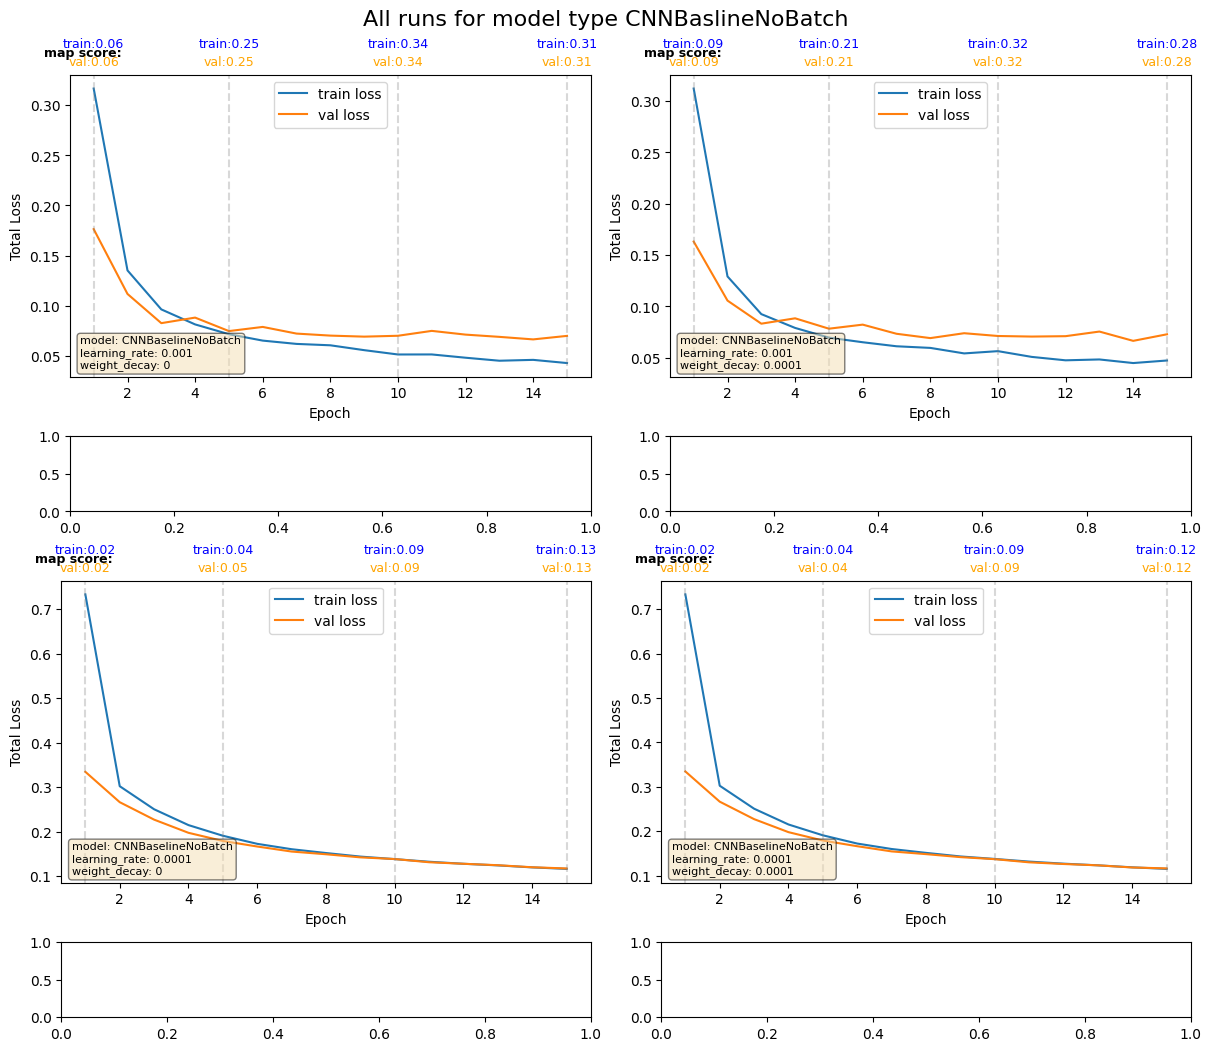

In [ ]:
runs = all_model_outcomes["CNNBaselineNoBatch"]
plot_all_runs(runs, "CNNBaslineNoBatch")
# fix these graphs with the weird table at the bottom

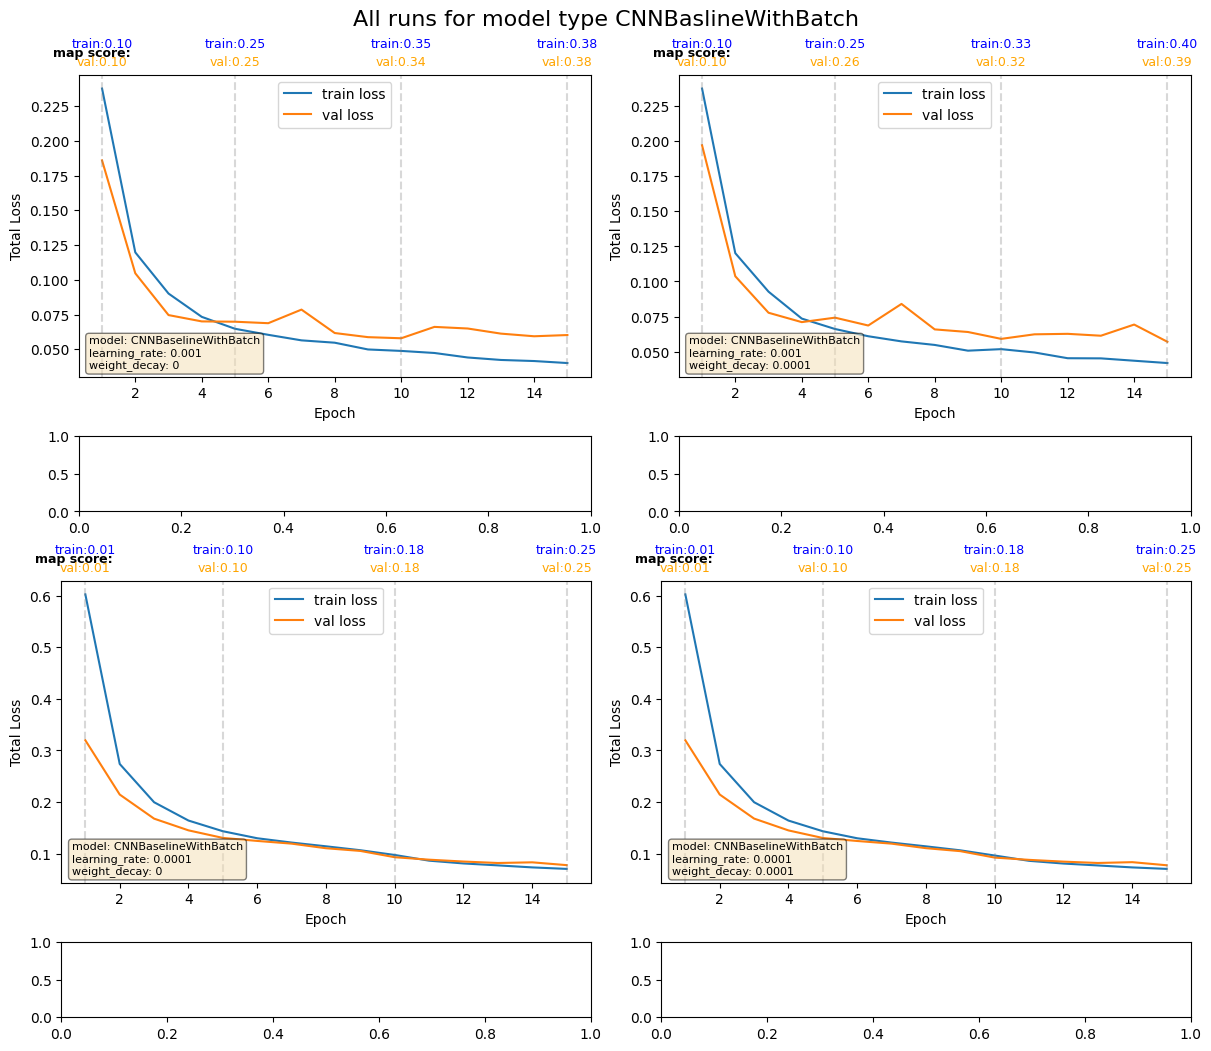

In [528]:
runs = all_model_outcomes["CNNBaselineWithBatch"]
plot_all_runs(runs, "CNNBaslineWithBatch")

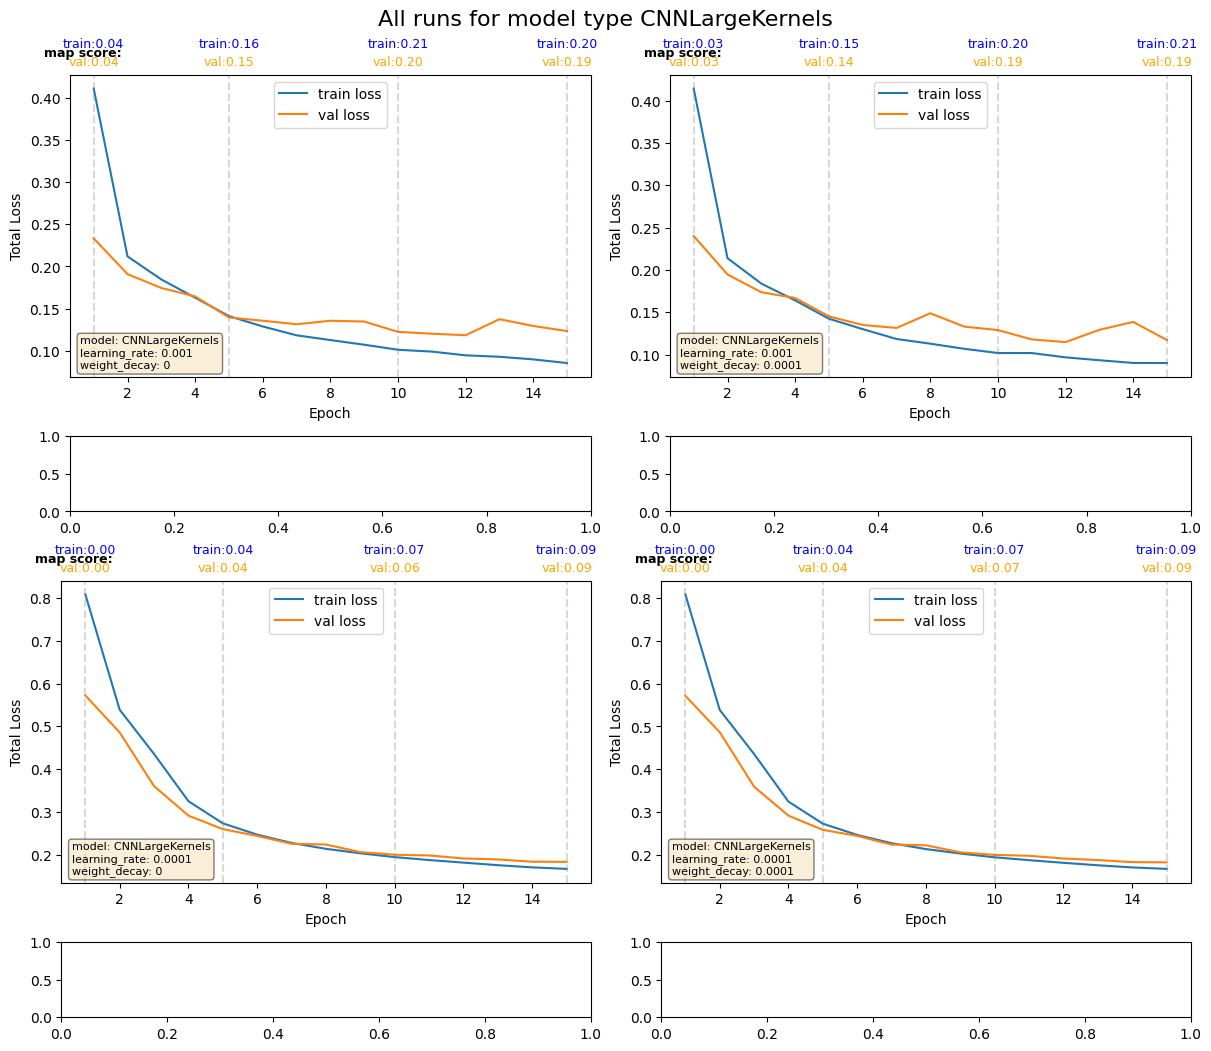

In [529]:
runs = all_model_outcomes["CNNLargeKernels"]
plot_all_runs(runs, "CNNLargeKernels")

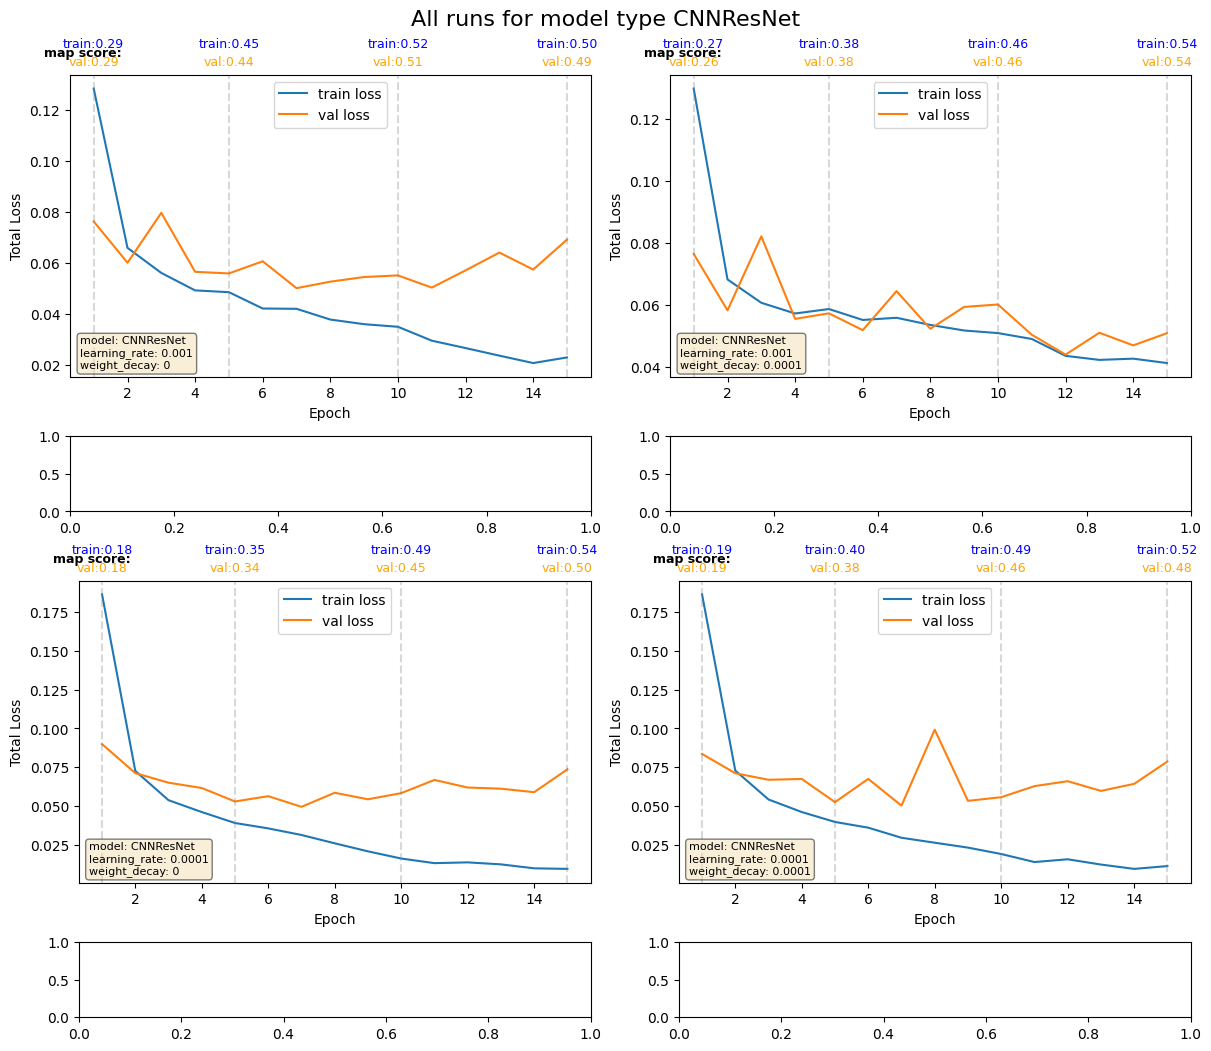

In [530]:
runs = all_model_outcomes["CNNResNet"]
plot_all_runs(runs, "CNNResNet")

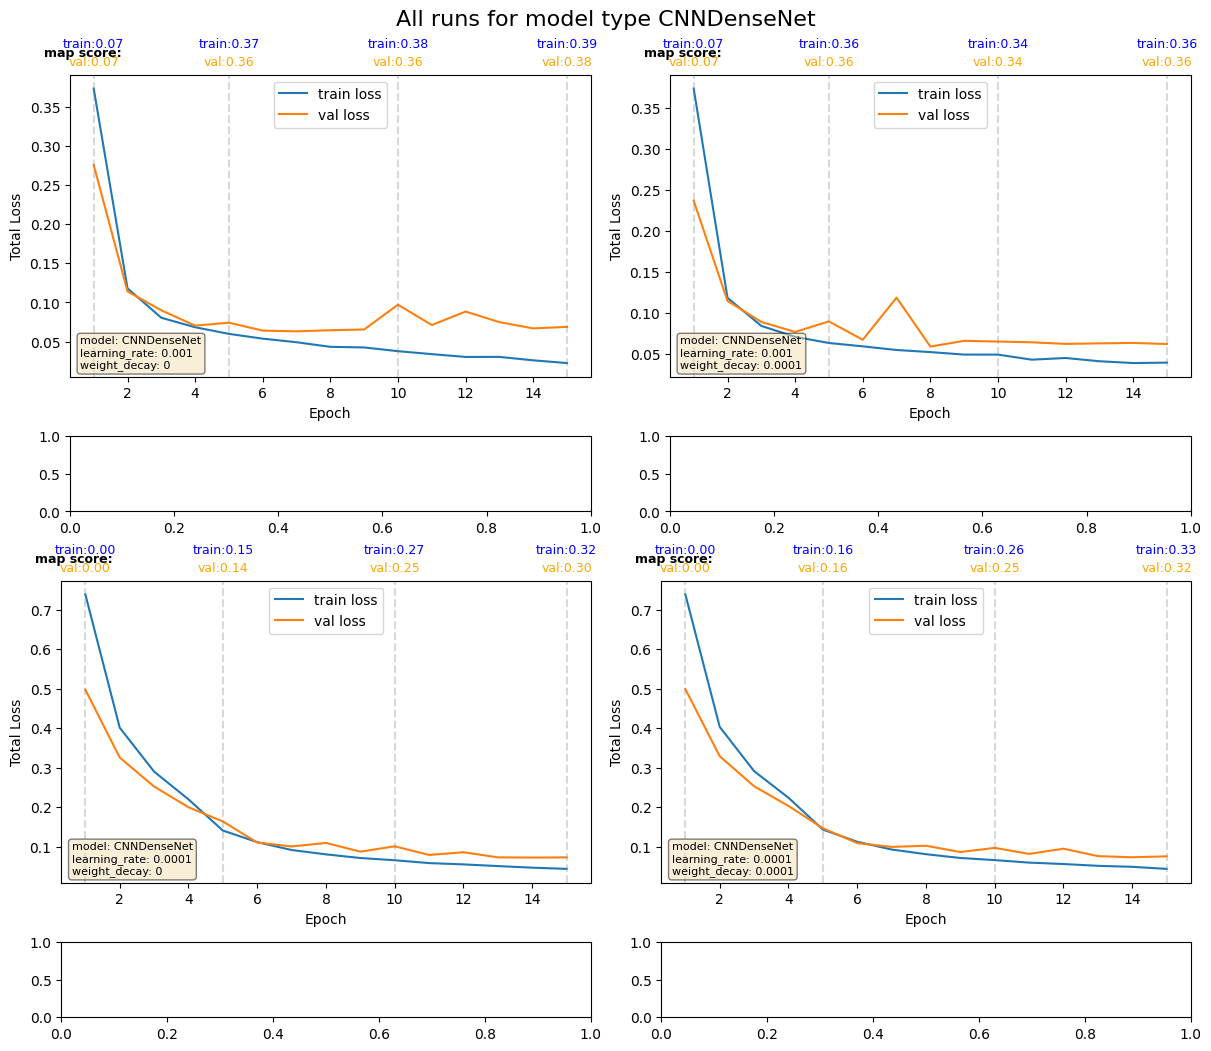

In [531]:
runs = all_model_outcomes["CNNDenseNet"]
plot_all_runs(runs, "CNNDenseNet")

In [532]:
best_model_outcome = None
best_score = -1.0
best_metrics = None
best_epoch = None

for model_name, runs in all_model_outcomes.items():
    for run in runs:
        for epoch, metrics in run.val_performance_metrics.items():
            current_score = metrics["map_50"]

            if current_score > best_score:
                best_score = current_score
                best_metrics = metrics
                best_model_outcome = run
                best_epoch = epoch

print(f"Best model: {best_model_outcome.params['model']}")
print(f"Best Score: {best_score:.4f} (Metrics: {best_metrics}) at {best_epoch} epochs")
print(f"Model path: {best_model_outcome.model_path}")

Best model: CNNResNet
Best Score: 0.9450 (Metrics: {'map': 0.5412862300872803, 'map_50': 0.9450370669364929, 'map_75': 0.5872510075569153, 'map_small': 0.5412862300872803, 'map_medium': -1.0, 'map_large': -1.0, 'mar_1': 0.5657455325126648, 'mar_10': 0.6249310970306396, 'mar_100': 0.6249310970306396, 'mar_small': 0.6249310970306396, 'mar_medium': -1.0, 'mar_large': -1.0, 'map_per_class': -1.0, 'mar_100_per_class': -1.0, 'classes': [0, 1]}) at 15 epochs
Model path: models/object_detection/f43cd3b5bc.pt


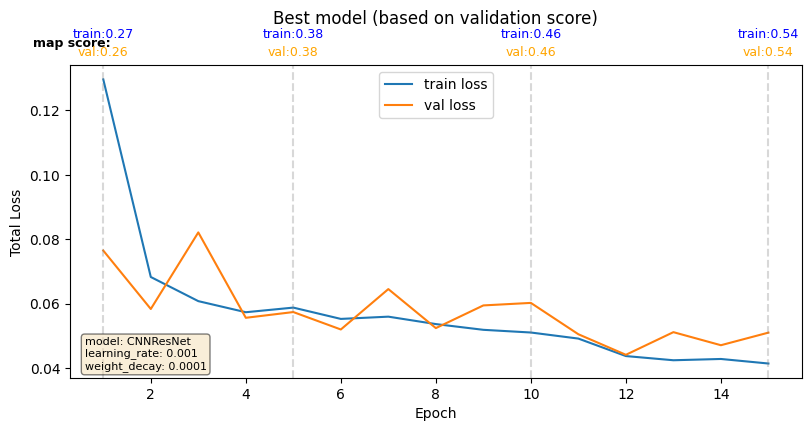

In [533]:
best_plot = plot_train_val_losses(
    train_losses=best_model_outcome.train_losses,
    val_losses=best_model_outcome.val_losses,
    train_acc=best_model_outcome.train_performance_metrics,
    val_acc=best_model_outcome.val_performance_metrics,
    params=best_model_outcome.params,
    title="Best model (based on validation score)"
)
plt.savefig(save_dir / "best_model.png")
plt.show()

In [534]:
model_class_name = best_model_outcome.params["model"]

if model_class_name == "CNNBaselineNoBatch":
    best_model = CNNBaselineNoBatch().to(device)
if model_class_name == "CNNBaselineWithBatch":
    best_model = CNNBaselineWithBatch().to(device)
if model_class_name == "CNNLargeKernels":
    best_model = CNNLargeKernels().to(device)
if model_class_name == "CNNResNet":
    best_model = CNNResNet().to(device)
if model_class_name == "CNNDenseNet":
    best_model = CNNDenseNet().to(device)

In [535]:
best_model.load_state_dict(torch.load(best_model_outcome.model_path))
best_model.eval()

CNNResNet(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): ResBlock(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (downsample2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (layer2): ResBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

## Performance measure

In [ ]:
# notes:
# num of layers affects size of receptive field
# kernel size affects ability to see complicated things
# we need to use MAP

# we could compute bounding boxes and accuracy

# since we can really have inifnite true negatives, we have to use precision

# precsion : TP / TP + FP <- we can abuse by placing few boxes
# recall : TP / TP + FN <- we can abuse by placing many many boxes

# MAP:
# mean precision is mean precision for one class

# if iou is more than half then we got a TP
# but if multiple, pick the one with highest IOU, rest are FN

### Model evaluation

In [537]:
def grab_predictions(model, dataset):
    all_preds = []
    all_actual = []

    with torch.no_grad():
        for imgs, actual_vector in dataset:
            imgs = imgs.to(device, dtype=torch.float32)
            actual_vector = actual_vector.to(device)

            pred_vector = model(imgs)

            all_preds.append(pred_vector.cpu())
            all_actual.append(actual_vector.cpu())

    return torch.cat(all_preds, dim=0), torch.cat(all_actual, dim=0)

In [538]:
all_preds_train, all_actual_train = grab_predictions(best_model, train_loader_grid)
all_preds_val, all_actual_val = grab_predictions(best_model, val_loader_grid)
all_preds_test, all_actual_test = grab_predictions(best_model, test_loader_grid)

In [539]:
train_map = get_map_results(best_model, train_loader_grid)
val_map = get_map_results(best_model, val_loader_grid)
test_map = get_map_results(best_model, test_loader_grid)

In [540]:
train_map

{'map': tensor(0.5442),
 'map_50': tensor(0.9434),
 'map_75': tensor(0.5976),
 'map_small': tensor(0.5442),
 'map_medium': tensor(-1.),
 'map_large': tensor(-1.),
 'mar_1': tensor(0.5676),
 'mar_10': tensor(0.6303),
 'mar_100': tensor(0.6303),
 'mar_small': tensor(0.6303),
 'mar_medium': tensor(-1.),
 'mar_large': tensor(-1.),
 'map_per_class': tensor(-1.),
 'mar_100_per_class': tensor(-1.),
 'classes': tensor([0, 1], dtype=torch.int32)}

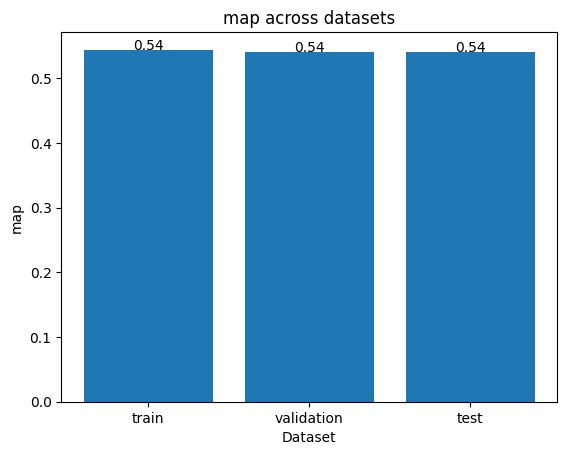

In [543]:
final_scores = {
    "train":  train_map["map"],
    "validation": val_map["map"],
    "test": test_map["map"],
}

score_across_datasets(final_scores, save_dir, metric = "map")

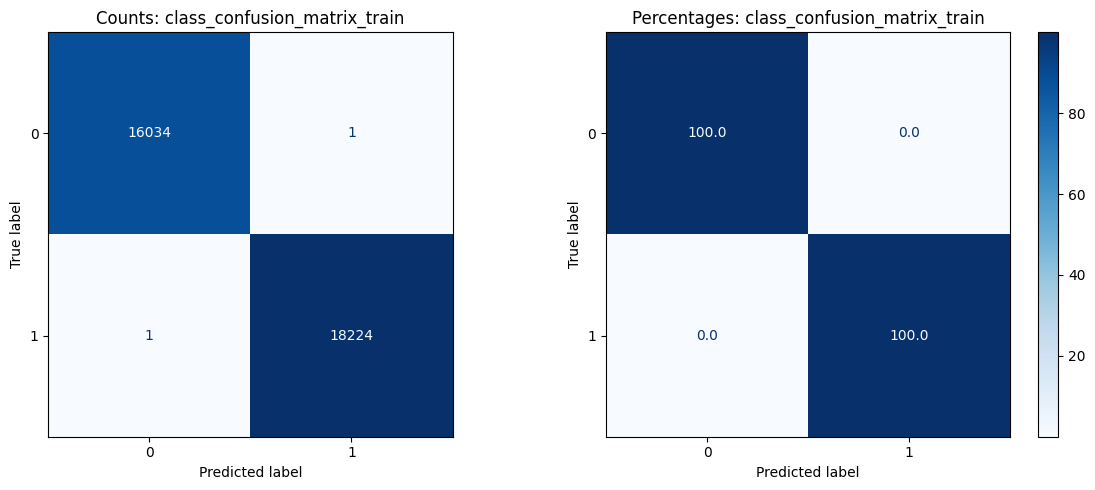

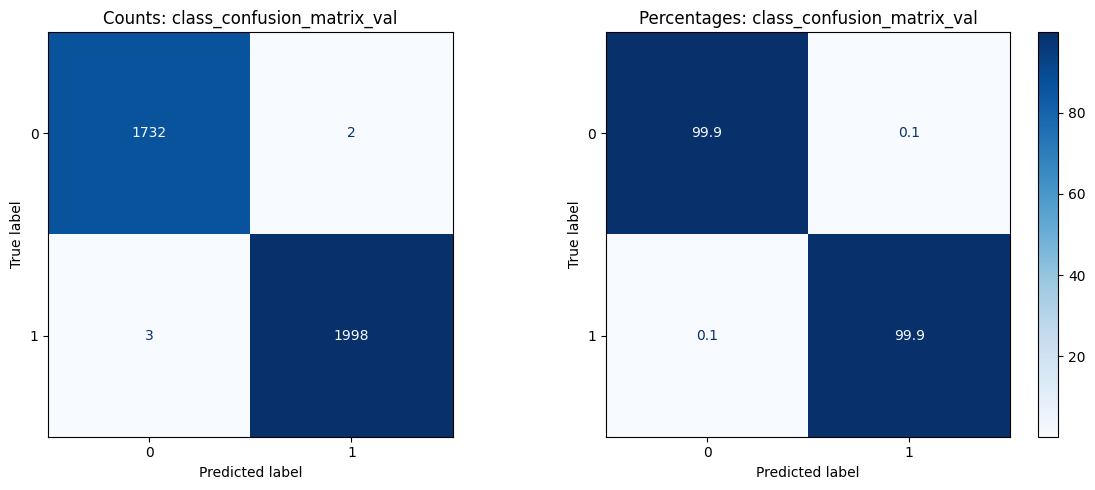

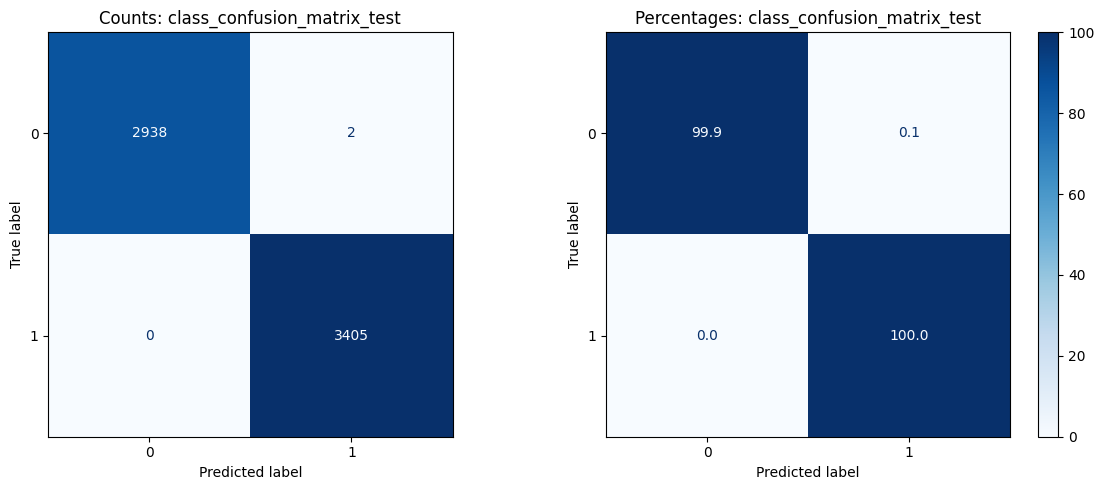

In [ ]:
# TODO:
def conf_matrix_class(all_preds, all_actual, dataset_name: str):
    if isinstance(all_preds, list):
        all_preds = torch.stack(all_preds)
    if isinstance(all_actual, list):
        all_actual = torch.stack(all_actual)

    # flatten n*2*3, 7
    preds_flat = all_preds.reshape(-1, all_preds.size(-1))
    actual_flat = all_actual.reshape(-1, all_actual.size(-1))

    # just pick those with more than 0.5 certainity
    mask = actual_flat[:, 0] > 0.5

    filtered_preds = preds_flat[mask]
    filtered_actual = actual_flat[mask]

    pred_labels = filtered_preds[:, 5:].argmax(dim=1)
    actual_labels = filtered_actual[:, 5].long()

    confusion_matrix_custom(
        actual_labels,
        pred_labels,
        f"class_confusion_matrix_{dataset_name}",
        dataset_name,
        iters=[0, 1],
        save_dir=save_dir
    )
conf_matrix_class(all_preds_train, all_actual_train, "train")
conf_matrix_class(all_preds_val, all_actual_val, "val")
conf_matrix_class(all_preds_test, all_actual_test, "test")

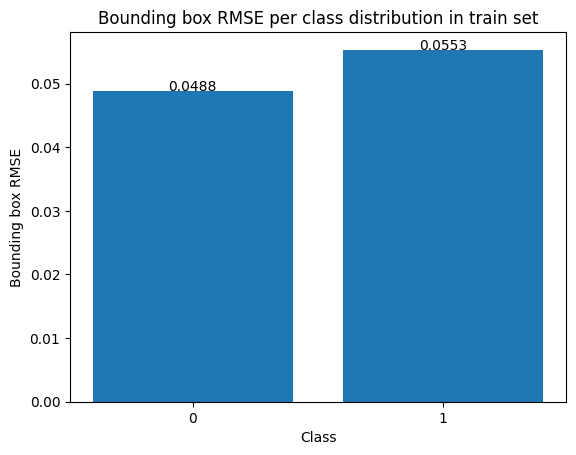

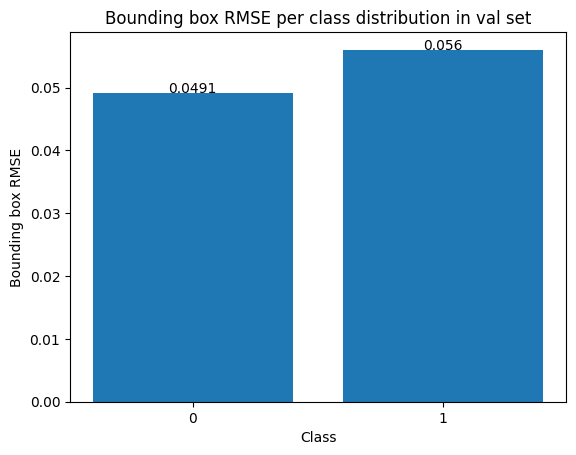

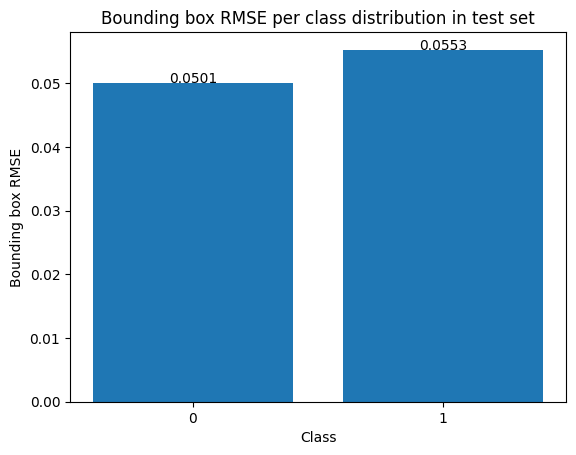

In [ ]:
def compute_rmse_arrs(actual_bb, pred_bb):
    actual_bb = torch.as_tensor(actual_bb)
    pred_bb = torch.as_tensor(pred_bb)
    criterion = nn.MSELoss()
    mse = criterion(pred_bb, actual_bb)
    return torch.sqrt(mse).item()

def get_rmse_bounding_boxes_per_class(all_preds, all_actual, all_actual_labels, set_label):
    rmse_dict = {}

    labels_int = all_actual_labels.astype(int)

    for cls in range(0,2):
        indexes = np.where(labels_int == cls)
        rmse_dict[cls] = compute_rmse_arrs(all_actual[indexes], all_preds[indexes])

    plt.bar(
        list(rmse_dict.keys()), list(rmse_dict.values()), label=rmse_dict.keys()
    )

    plt.xlabel("Class")
    plt.ylabel("Bounding box RMSE")
    plt.title(f"Bounding box RMSE per class distribution in {set_label} set")
    plt.xticks([i for i in range(0,2)])

    for x, y in rmse_dict.items():
        plt.text(x, y, f"{y:.3}", ha="center")

    plt.savefig(save_dir / f"bb_rmse_{set_label}.png")
    plt.show()

def rmse_bb(all_preds, all_actual, dataset: str):
    # flatten
    actual_flat = all_actual.reshape(-1, all_actual.size(-1))
    preds_flat = all_preds.reshape(-1, all_preds.size(-1))

    # only if they actually have object
    mask = actual_flat[:, 0] == 1

    actual_bb = actual_flat[mask, 1:5]
    pred_bb = preds_flat[mask, 1:5]
    all_actual_labels = actual_flat[mask, 5]

    get_rmse_bounding_boxes_per_class(
        pred_bb,
        actual_bb,
        all_actual_labels,
        dataset
    )

rmse_bb(all_preds_train, all_actual_train, "train")
rmse_bb(all_preds_val, all_actual_val, "val")
rmse_bb(all_preds_test, all_actual_test, "test")

In [ ]:
def get_all_raw_boxes(predictions, confidence_threshold=0.1):
    rows, cols = predictions.shape[0], predictions.shape[1]
    all_boxes = []

    for r in range(rows):
        for c in range(cols):
            vec = predictions[r, c]
            pc = torch.sigmoid(vec[0]).item()

            if confidence_threshold:
                if pc < confidence_threshold:
                    continue

            x_l, y_l, w_l, h_l = torch.sigmoid(vec[1:5])
            x_g, y_g, w_g, h_g = local_to_global(x_l, y_l, w_l, h_l, row=r, col=c)

            c1, c2 = vec[5:]
            cls = 0 if c1 > c2 else 1

            all_boxes.append({
                "full_vector": [pc, x_g, y_g, w_g, h_g, c1, c2],
                "class": cls,
                "confidence": pc
            })

    return all_boxes

In [681]:
def non_max_supression(predictions, iou_threshold=0.5, confidence_threshold = 0.5):
    global_preds = get_all_raw_boxes(predictions, confidence_threshold=confidence_threshold)

    global_preds.sort(key=lambda x: x["confidence"], reverse=True)

    keep = []
    while global_preds:
        chosen = global_preds.pop(0)
        keep.append(chosen)

        global_preds_to_keep = []
        for p in global_preds:
            if p["class"] != chosen["class"]: # different class is ok
                global_preds_to_keep.append(p)
            else:
                union, inter = intersection_union(chosen["full_vector"], p["full_vector"])
                if inter / (union + 0.00000001) < iou_threshold:
                    global_preds_to_keep.append(p)

        global_preds = global_preds_to_keep

    return keep

In [682]:
def plot_image_with_predictions(img_inp, ax, predictions_to_draw):
    img_pixels, global_coords_ls = img_inp
    img = img_pixels.permute(1, 2, 0).cpu().numpy()
    ax.imshow(img, cmap = "gray")

    # cell lines
    for r in range(1, TOTAL_ROWS):
        ax.axhline(y=r * IMG_HEIGHT / TOTAL_ROWS, color='white', linestyle='--', linewidth=1)
    for c in range(1, TOTAL_COLS):
        ax.axvline(x=c * IMG_WIDTH / TOTAL_COLS, color='white', linestyle='--', linewidth=1)

    items_in_img = []
    for coords in global_coords_ls:
        pc, x, y, w, h, class_label = coords
        items_in_img.append(int(class_label))
        sx, sy, sw, sh = scale_vars(x, y, w, h)
        ax.add_patch(patches.Rectangle((sx, sy), sw, sh, linewidth=1, edgecolor='r', facecolor='none'))

    predicted_classes = []
    for pred in predictions_to_draw:
        yes_no, x_g, y_g, w_g, h_g, _c1, _c2 = pred["full_vector"]

        # xy box stuff
        corner_x = x_g - (w_g / 2)
        corner_y = y_g - (h_g / 2)

        cls = pred["class"]
        predicted_classes.append(cls)

        sx_p, sy_p, sw_p, sh_p = scale_vars(corner_x, corner_y, w_g, h_g)

        ax.add_patch(
            patches.Rectangle((sx_p, sy_p), sw_p, sh_p, linewidth=2, edgecolor='b', facecolor='none')
        )

        # text for each box
        ax.text(sx_p, sy_p, f"P:{cls}|R,C:{row},{col}", color='yellow', fontsize=8, backgroundcolor='black')

    legend_elements = [Patch(facecolor='none', edgecolor='r', label='Actual'),
                       Patch(facecolor='none', edgecolor='b', label='Predicted')]
    ax.legend(handles=legend_elements, loc='upper right')
    ax.set_title(f"Actual: {items_in_img}, Pred: {predicted_classes}")

    return ax

In [683]:
def plot_multiple_with_prediction(indicies: list,
                                  prediction: list,
                                  title: str,
                                  dataset,
                                  model_title,
                                  non_max_supression_iou = 0.5,
                                  non_max_supression_confidence = 0.5
                                  ):
    n = len(indicies)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    fig.suptitle(f"{title}", fontsize=16)

    for ax, index in zip(axes, indicies):
        predictions_to_draw = non_max_supression(
            prediction[index],
            confidence_threshold=non_max_supression_confidence,
            iou_threshold=non_max_supression_iou
        )
        plot_image_with_predictions(dataset[index], ax, predictions_to_draw)

    for i in range(n, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    fig.savefig(save_dir / f"{model_title}.png", dpi=500)

    plt.show()

In [684]:
def plot_multiple_with_prediction(indicies: list,
                                  predictions: list,
                                  title: str,
                                  actual,
                                  model_title,
                                  ):
    n = len(indicies)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    fig.suptitle(f"{title}", fontsize=16)

    for ax, true, pred in zip(axes, actual, predictions):
        plot_image_with_predictions(true, ax, pred)

    for i in range(n, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    fig.savefig(save_dir / f"{model_title}.png", dpi=500)

    plt.show()

In [685]:
img_to_show = 15
preds_val = [all_preds_train[i] for i in range(img_to_show)]

In [686]:
dataset_train_processed[0][1]

[tensor([1.0000, 0.2583, 0.4062, 0.1167, 0.3958, 1.0000]),
 tensor([1.0000, 0.6500, 0.6667, 0.2333, 0.3333, 0.0000])]

In [687]:
all_preds_train[0]

tensor([[[-9.6115,  0.6808,  0.6517,  1.0026,  0.3698, -0.7465,  0.5997],
         [-8.6249,  0.6022,  0.7763,  0.9548,  0.3698, -2.4056,  2.1868],
         [-9.9043,  0.4544,  0.7119,  0.9741,  0.4117, -0.1902, -0.0235]],

        [[-9.8439,  0.7331,  0.4690,  0.9553,  0.3542, -1.2162,  1.0859],
         [-7.4011,  0.6801,  0.4774,  0.8782,  0.2513, -1.0404,  0.9418],
         [ 8.6576,  0.4578,  0.4623,  1.3034,  0.6638,  7.4561, -7.7486]]])

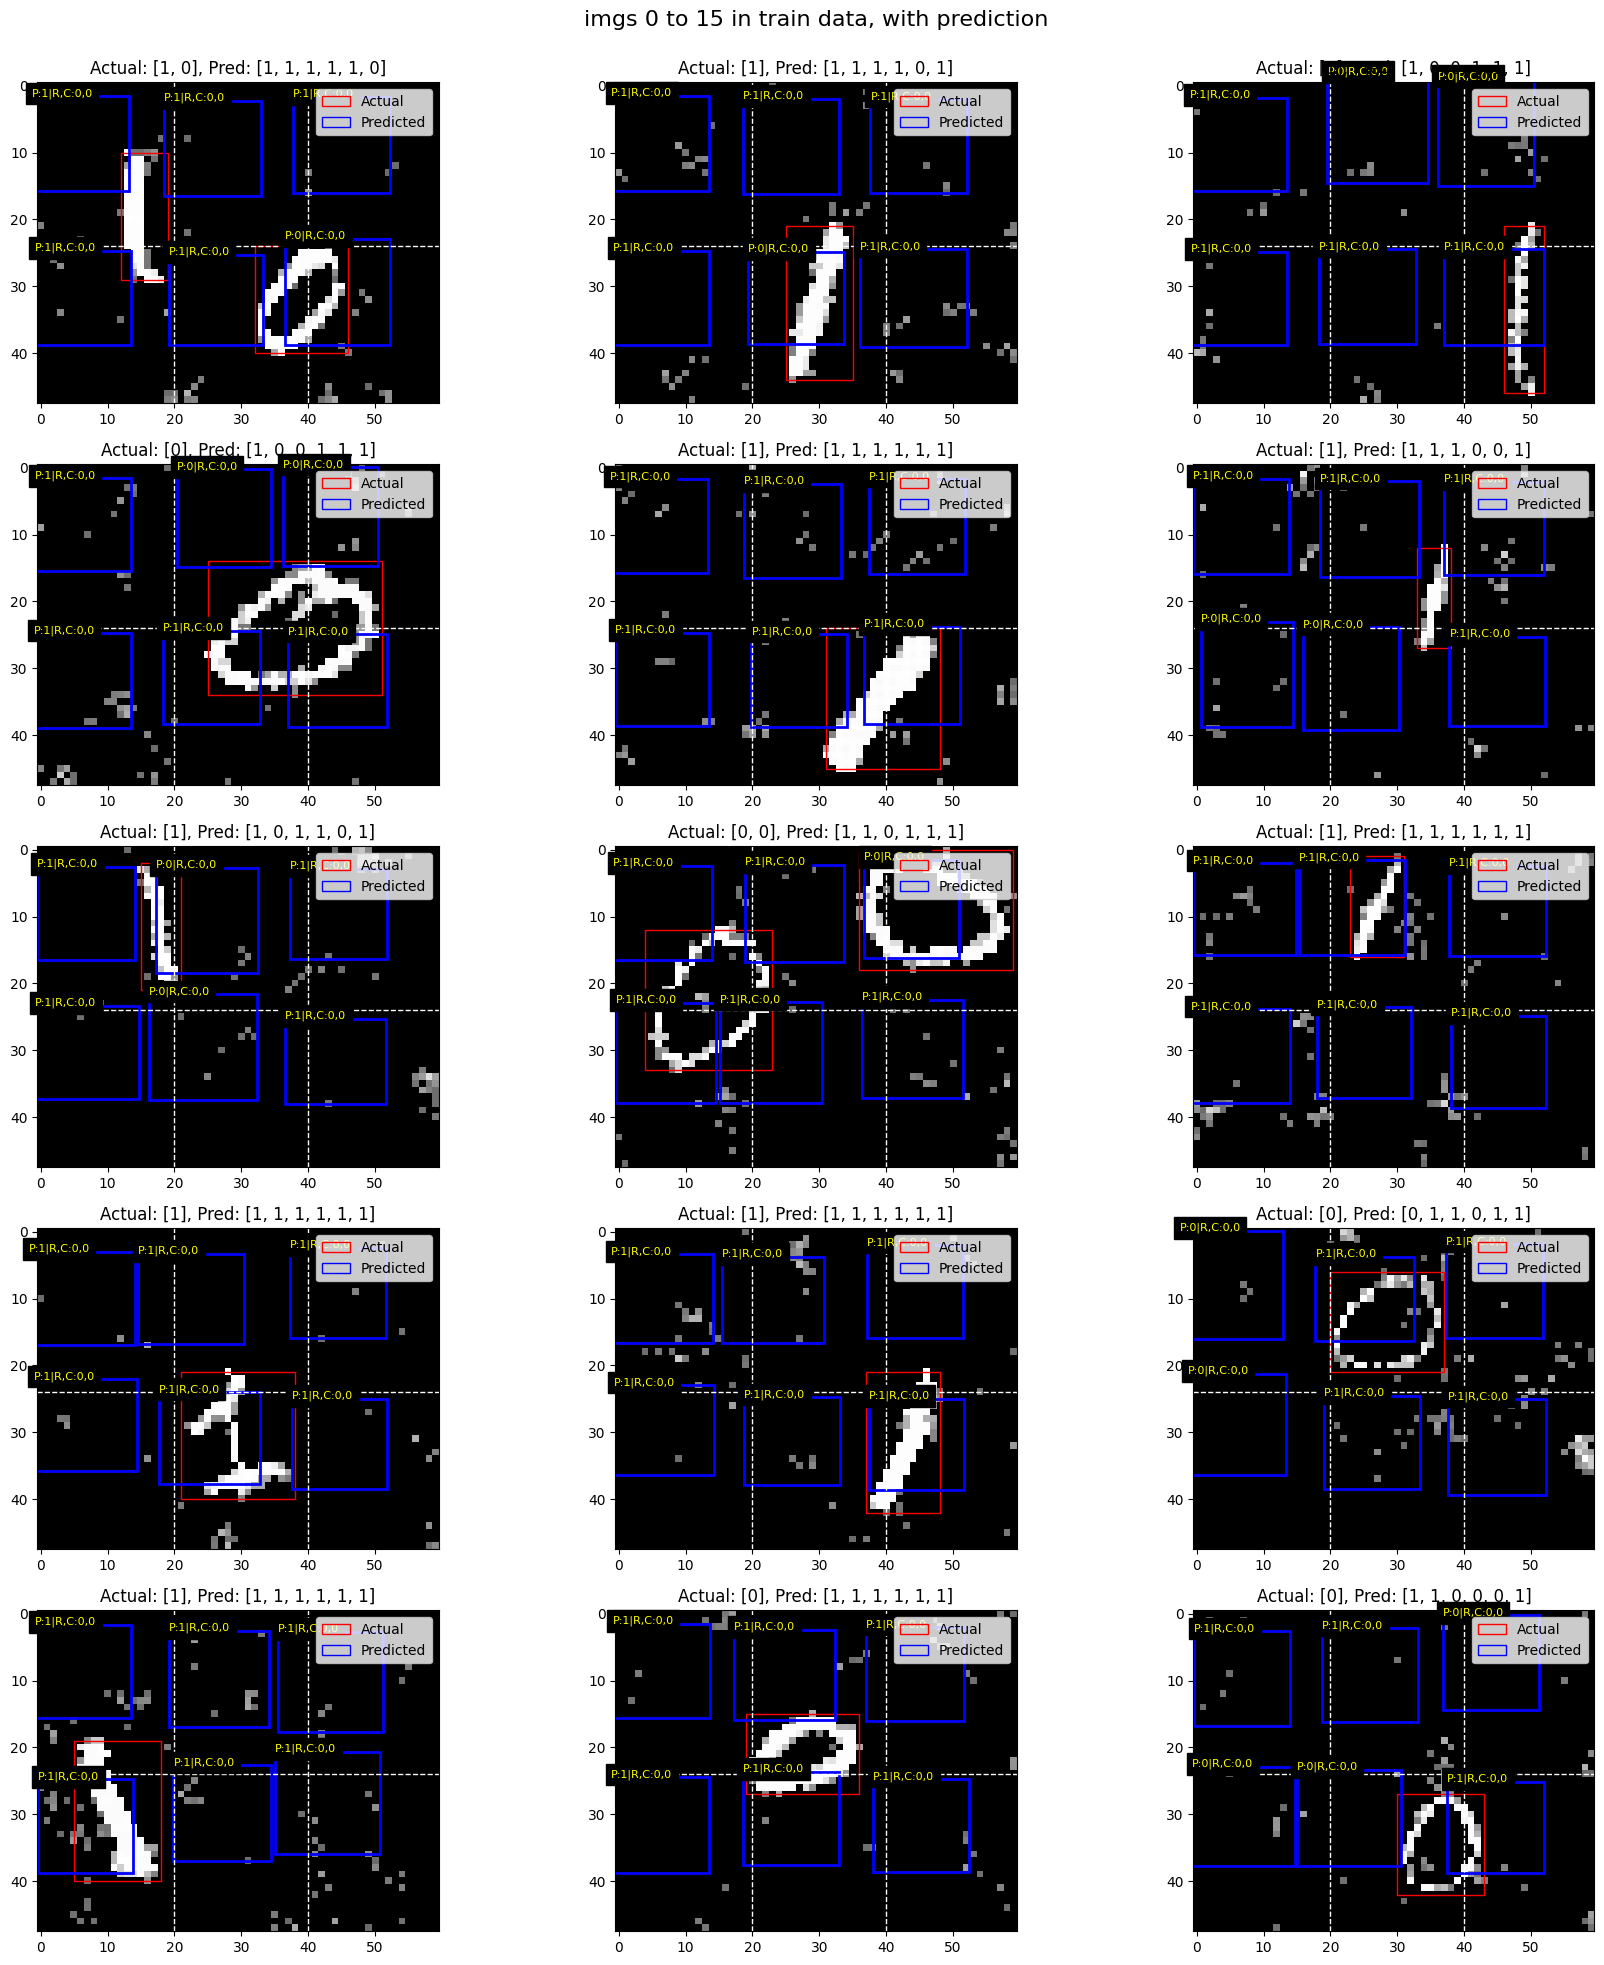

In [688]:
train_preds = []
train_actual = []
for i in range(img_to_show):
    train_preds.append(
        get_all_raw_boxes(
            all_preds_train[i],
            confidence_threshold=None,
        )
    )
    train_actual.append(
        dataset_train_processed[i]
    )

plot_multiple_with_prediction(
    [i for i in range(img_to_show)],
    train_preds,
    f"imgs 0 to {img_to_show} in train data, with prediction",
    train_actual,
    "data_predict_train_all_imgs"
)
# all boxes

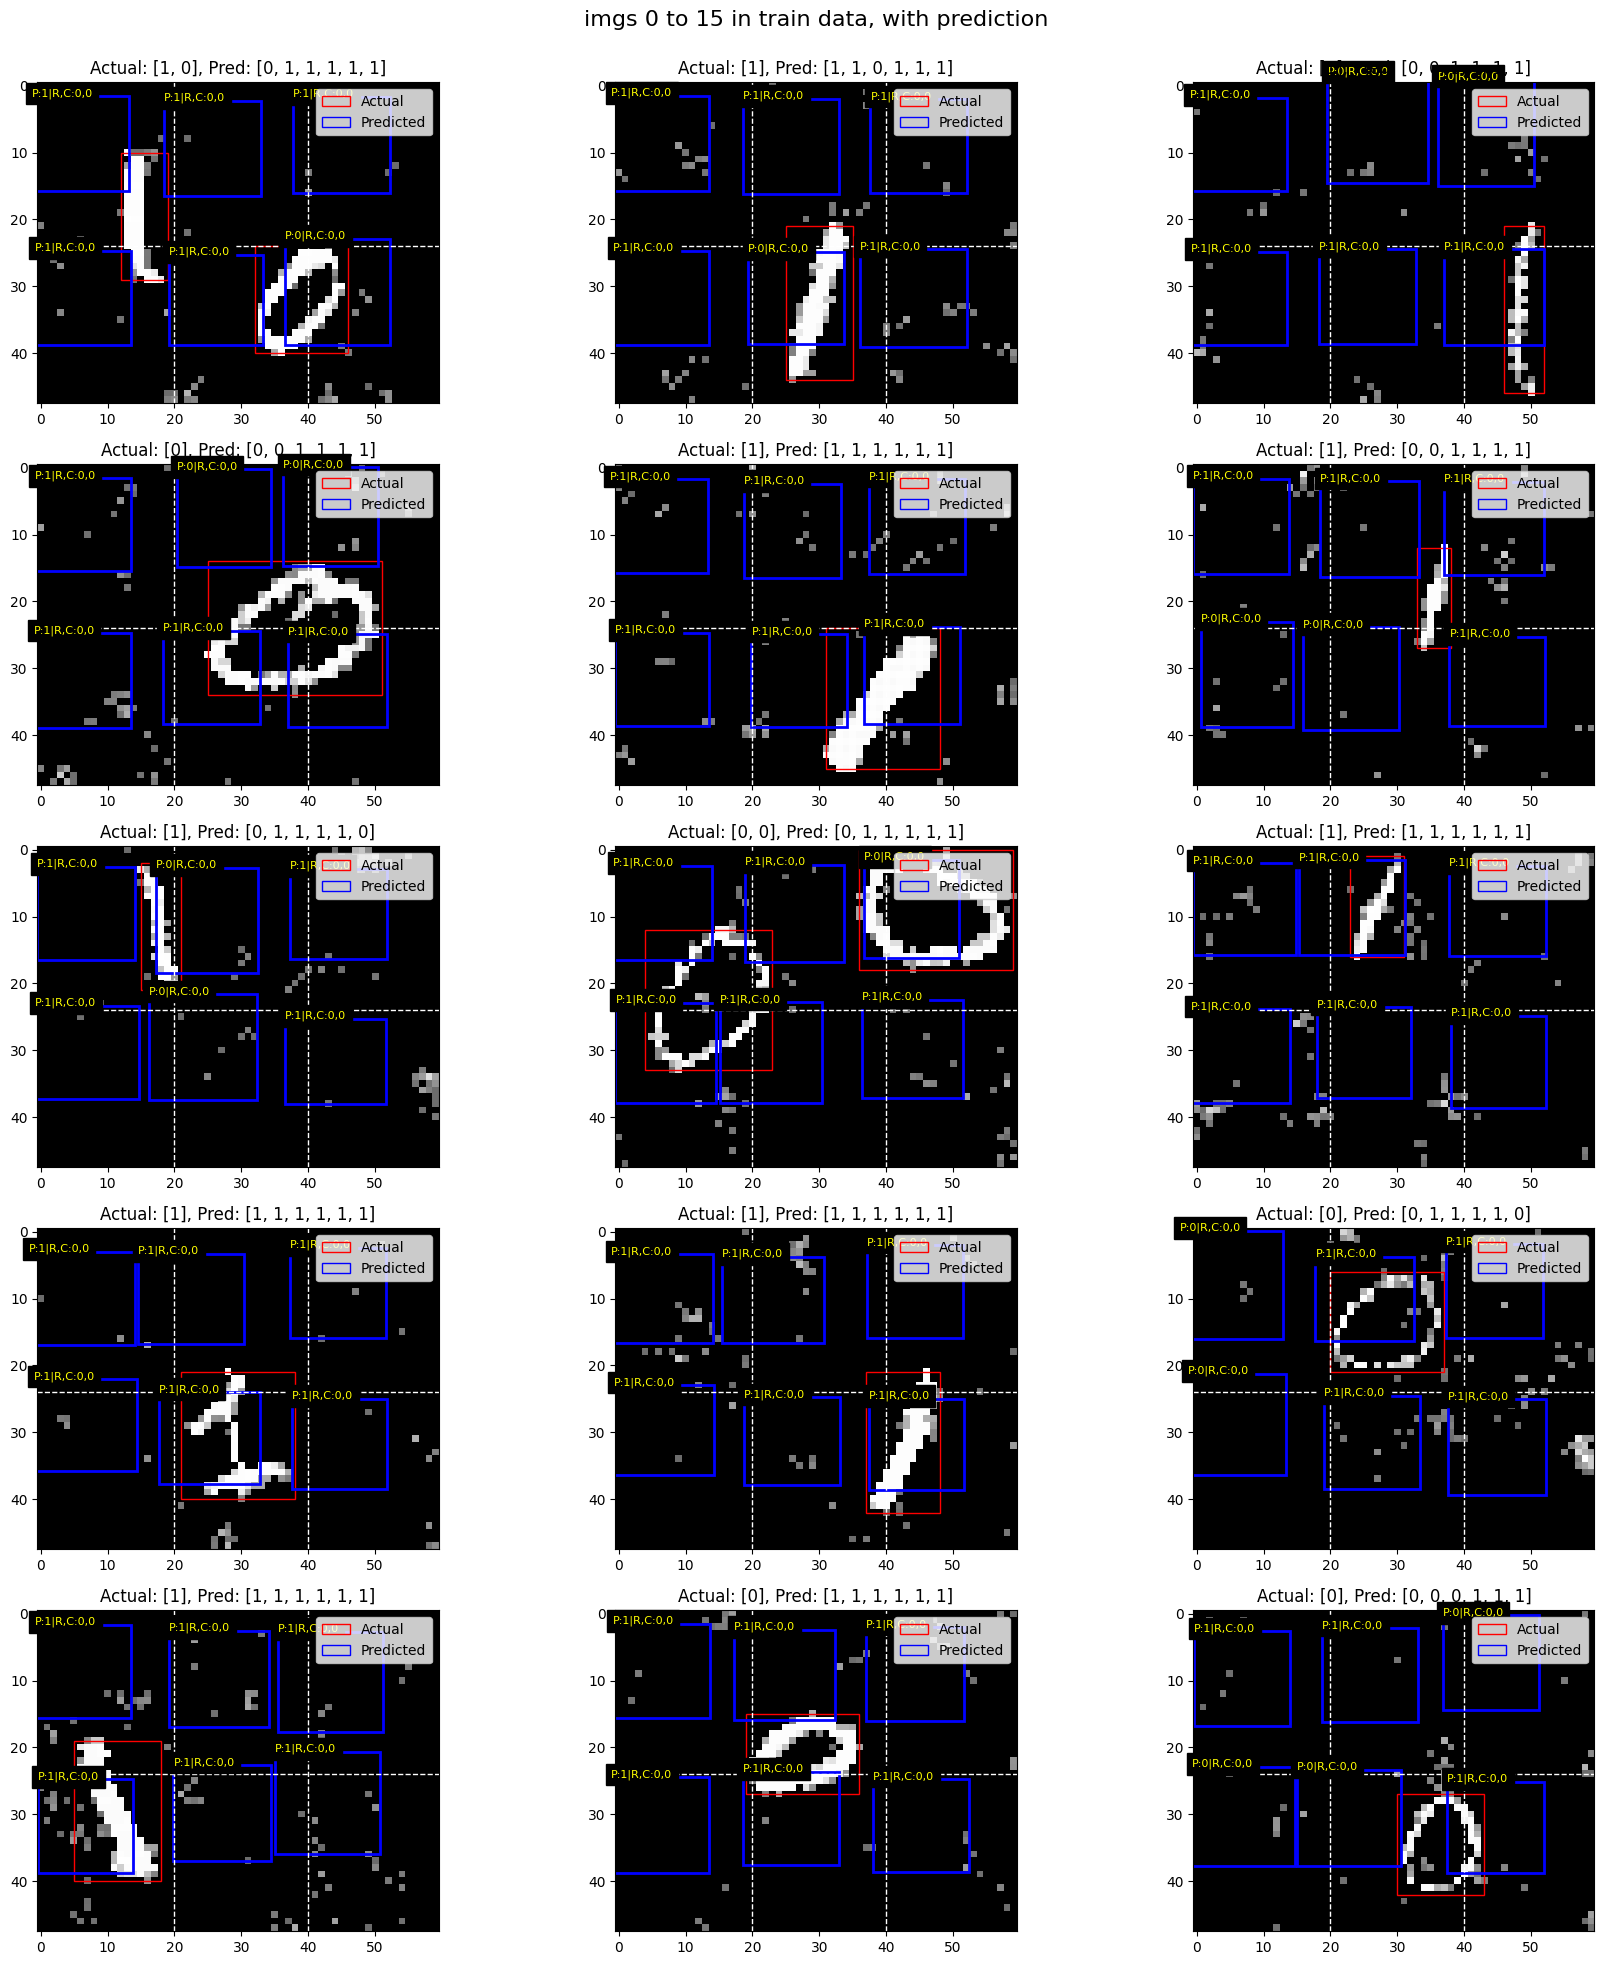

In [693]:
train_preds = []
train_actual = []
for i in range(img_to_show):
    train_preds.append(
        non_max_supression(
            all_preds_train[i],
            confidence_threshold=None,
            iou_threshold=0.5 # if there is some overlap
        )
    )
    train_actual.append(
        dataset_train_processed[i]
    )

plot_multiple_with_prediction(
    [i for i in range(img_to_show)],
    train_preds,
    f"imgs 0 to {img_to_show} in train data, with prediction",
    train_actual,
    "data_predict_train_all_imgs"
)

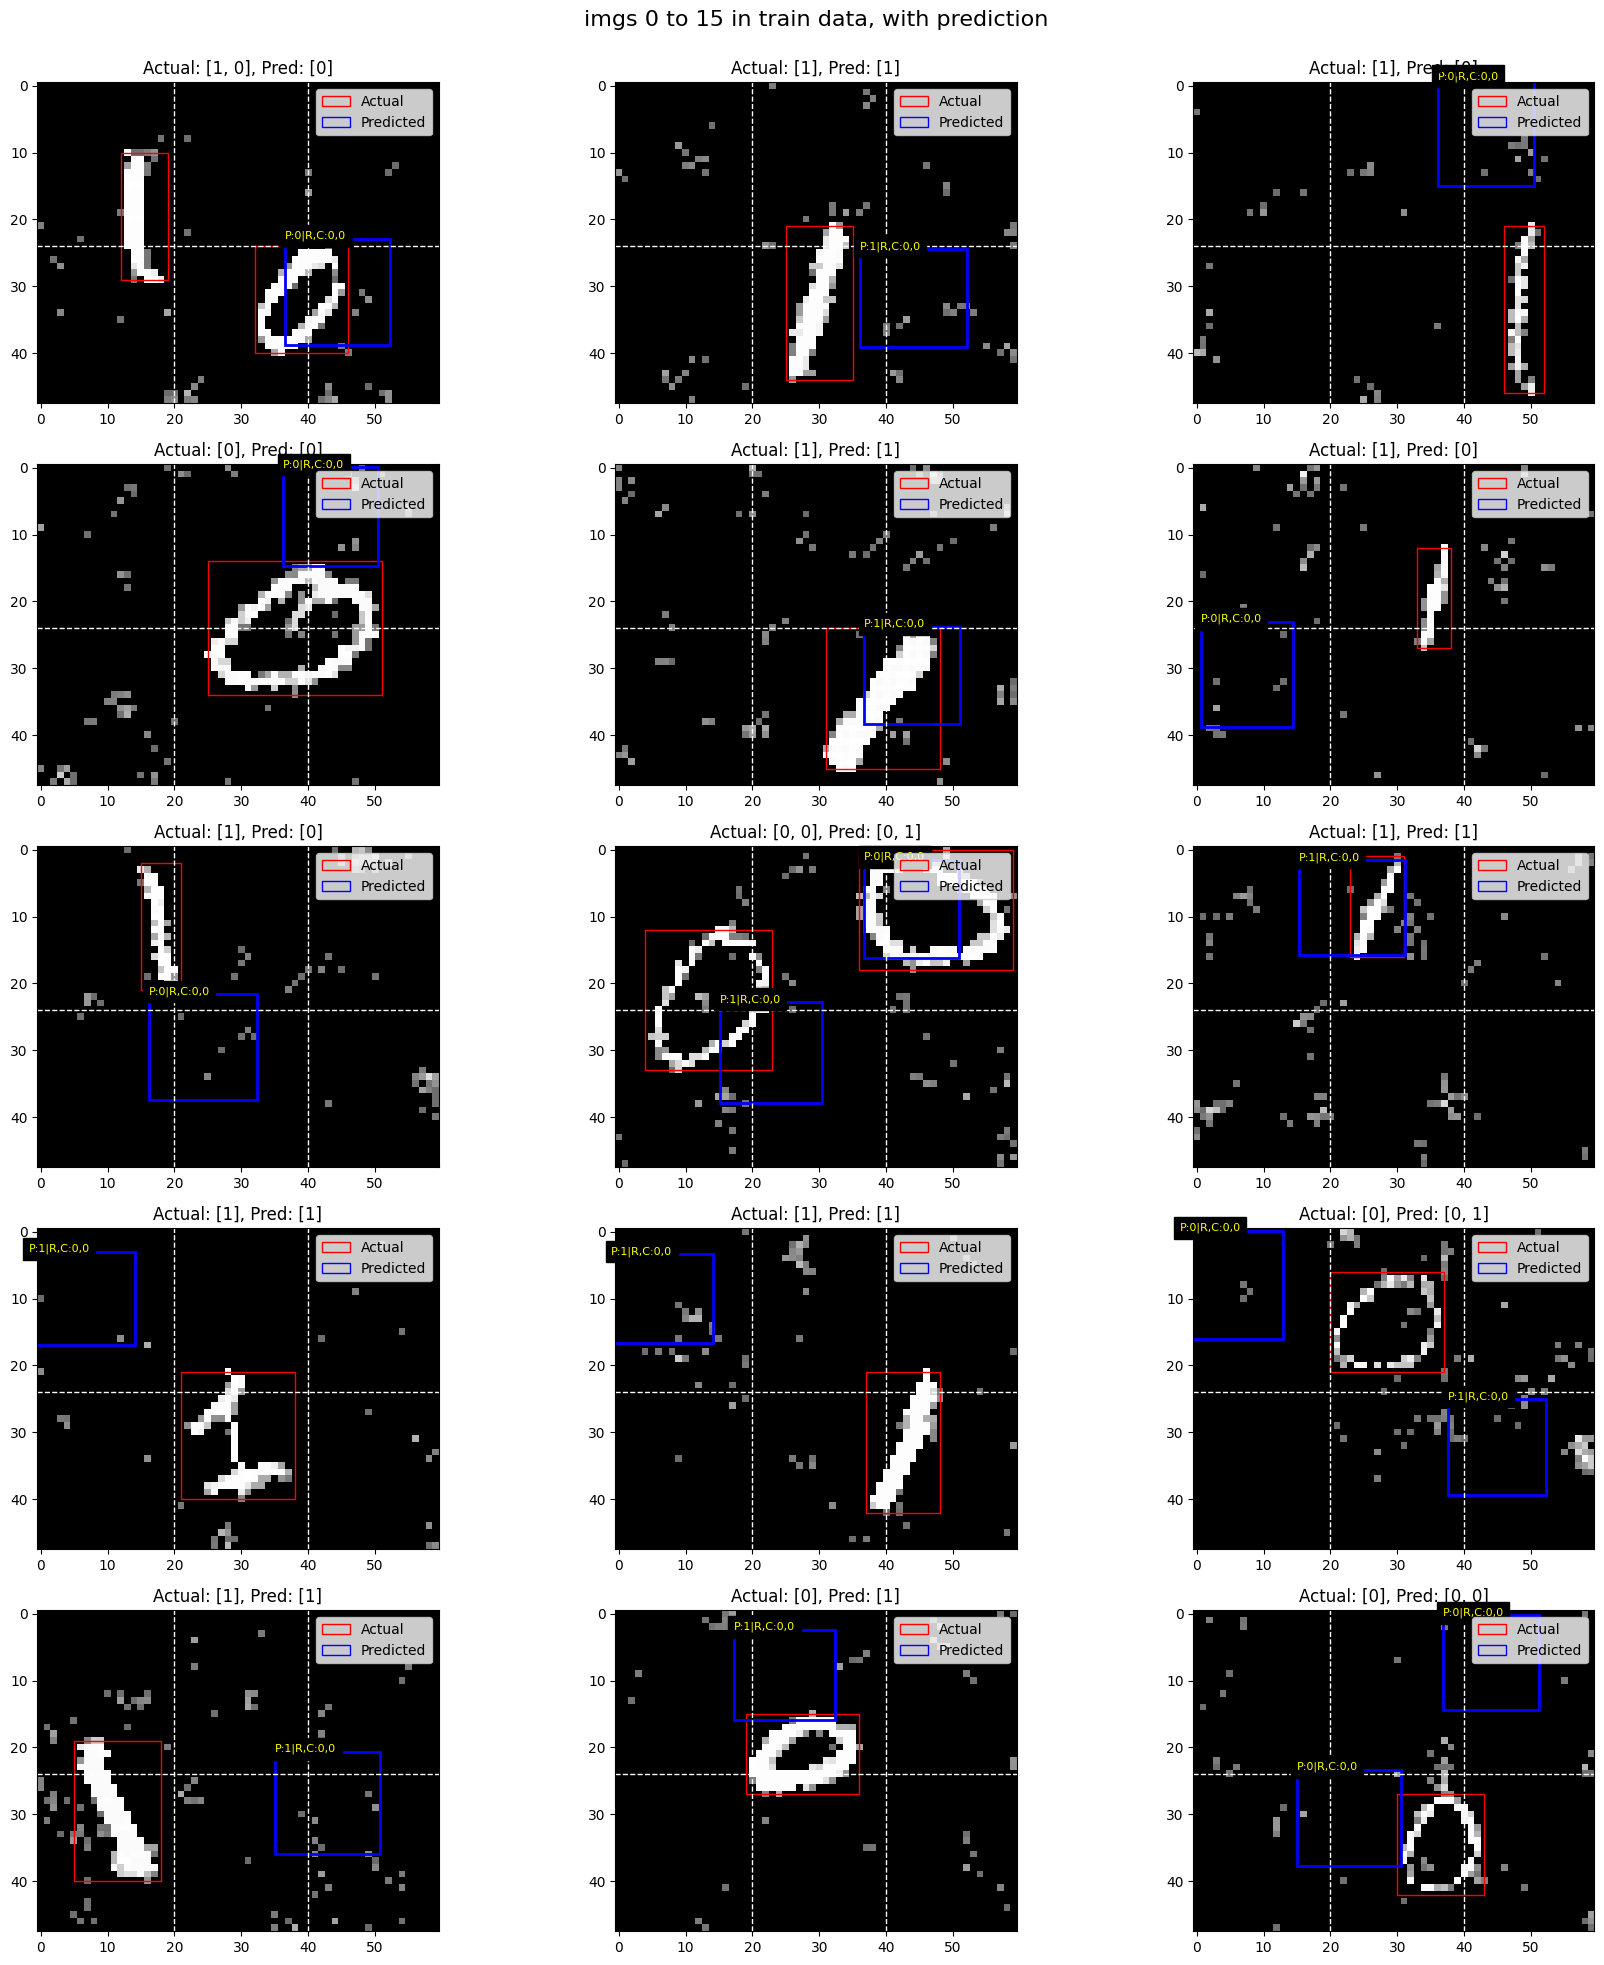

In [697]:
train_preds = []
train_actual = []
for i in range(img_to_show):
    train_preds.append(
        non_max_supression(
            all_preds_train[i],
            confidence_threshold=0.5,
            iou_threshold=0.5
        )
    )
    train_actual.append(
        dataset_train_processed[i]
    )

plot_multiple_with_prediction(
    [i for i in range(img_to_show)],
    train_preds,
    f"imgs 0 to {img_to_show} in train data, with prediction",
    train_actual,
    "data_predict_train_all_imgs"
)